In [1]:
import os
import json
import pandas as pd
import glob

# 🌟 你的结果根目录 (根据你的截图推断)
base_dir = "./results/criteo/train_y/TARNET"

# 5 个消融实验的目录名
versions = [
    "y_v1_base", 
    "y_v2_emb", 
    "y_v5_loss_var", 
    "y_v5_loss_var", 
    "y_v5_loss_var"
]

# 🎯 我们要重点对比的指标池
metrics_to_extract = [
    "Test_Target_Y_AUUC", 
    "Valid_Target_Y_AUUC",
    # "Test_Target_Y_Lift@10", 
    # "Test_Target_Y_Lift@30",
    # "Test_Target_Y_AUC",      # 看基础分类能力有没有崩
    "Test_Target_Y_PCOC",     # 看校准度有没有飘
    "Valid_Target_C_AUUC",
    "Test_Target_C_AUUC"      # 看 C 的因果信号保留情况
]

results = []

print("🔍 正在扫描文件...")
for v in versions:
    # 巧妙使用 glob 跳过中间的 exp_name 目录，直接定位 json
    search_pattern = os.path.join(base_dir, v, "*", "final_metrics.json")
    found_files = glob.glob(search_pattern)
    
    if not found_files:
        print(f"⚠️ 找不到 {v} 的 final_metrics.json，可能还没跑完？")
        continue
        
    json_path = found_files[0]
    
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    # 组装这一行的数据
    row = {"Version": v}
    for m in metrics_to_extract:
        val = data.get(m, None)
        # 统一保留 4 位小数，看起来清爽
        row[m] = round(val, 4) if isinstance(val, float) else val
        
    results.append(row)

# ==========================================
# 📊 打印华丽的对比战报
# ==========================================
if results:
    df = pd.DataFrame(results)
    df.set_index("Version", inplace=True)
    
    # 强制 Pandas 在终端里不折叠列
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    print("\n" + "="*90)
    print("🚀 Uplift 消融实验 (Stage 3) 核心指标对比战报 🚀")
    print("="*90)
    # 按顺序打印我们要看的列
    print(df[metrics_to_extract])
    print("="*90)
else:
    print("❌ 没有提取到任何数据，请检查 base_dir 路径是否正确！")

🔍 正在扫描文件...

🚀 Uplift 消融实验 (Stage 3) 核心指标对比战报 🚀
               Test_Target_Y_AUUC  Valid_Target_Y_AUUC  Test_Target_Y_PCOC  Valid_Target_C_AUUC  Test_Target_C_AUUC
Version                                                                                                            
y_v1_base                  0.8839               0.8933              1.0158               0.7863              0.7762
y_v2_emb                   0.8723               0.8965              1.0872               0.7491              0.7451
y_v5_loss_var              0.8904               0.8903             25.1867               0.7639              0.7690
y_v5_loss_var              0.8904               0.8903             25.1867               0.7639              0.7690
y_v5_loss_var              0.8904               0.8903             25.1867               0.7639              0.7690


In [2]:
import os
import json
import pandas as pd
import glob

base_dir = "./results/criteo/train_y/TARNET"
versions = ["y_v1_base", "y_v2_emb", "y_v5_loss_var", "y_v5_loss_var", "y_v5_loss_var"]

metrics_to_extract = [
    "Test_Target_Y_AUUC", 
    "Test_Target_Y_AUC",      # 异常点 1: < 0.5 说明预测完全反转
    "Test_Target_Y_PCOC",     # 异常点 2: 偏离 1.0 说明极度高估/低估
    "Test_Target_Y_MAE",      # 异常点 3: 绝对误差，越小越好
    "Test_Target_Y_Lift@10", 
]

results = []
for v in versions:
    search_pattern = os.path.join(base_dir, v, "*", "final_metrics.json")
    found_files = glob.glob(search_pattern)
    if not found_files: continue
    with open(found_files[0], 'r') as f: data = json.load(f)
    row = {"Version": v}
    for m in metrics_to_extract:
        val = data.get(m, None)
        row[m] = round(val, 4) if isinstance(val, float) else val
    results.append(row)

if results:
    df = pd.DataFrame(results).set_index("Version")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    print("\n" + "="*90)
    print("🚀 Uplift 消融实验 (Stage 3) - 异常诊断战报 🚀")
    print("="*90)
    print(df[metrics_to_extract])
    print("="*90)


🚀 Uplift 消融实验 (Stage 3) - 异常诊断战报 🚀
               Test_Target_Y_AUUC  Test_Target_Y_AUC  Test_Target_Y_PCOC  Test_Target_Y_MAE  Test_Target_Y_Lift@10
Version                                                                                                           
y_v1_base                  0.8839             0.9210              1.0158             0.0056                 0.0086
y_v2_emb                   0.8723             0.1610              1.0872             0.0061                 0.0077
y_v5_loss_var              0.8904             0.0933             25.1867             0.0763                 0.0079
y_v5_loss_var              0.8904             0.0933             25.1867             0.0763                 0.0079
y_v5_loss_var              0.8904             0.0933             25.1867             0.0763                 0.0079


In [3]:
import os
import glob
import pandas as pd
import numpy as np

base_dir = "./results/criteo/train_y/TARNET"
versions = ["y_v1_base", "y_v2_emb", "y_v5_loss_var", "y_v5_loss_var", "y_v5_loss_var"]

results = []

print("🔍 正在扫描 test_dist.csv 并分析预测分布...")
for v in versions:
    # 自动寻找 test_dist.csv
    search_pattern = os.path.join(base_dir, v, "*", "test_dist.csv")
    found_files = glob.glob(search_pattern)
    
    if not found_files:
        continue
        
    csv_path = found_files[0]
    df = pd.read_csv(csv_path)
    
    # 提取真实大盘转化率
    true_ctr = df['y_true'].mean()
    
    # 分析预测的分布特征
    y0_mean = df['y0_prob'].mean()
    y1_mean = df['y1_prob'].mean()
    uplift_mean = df['uplift_pred'].mean()
    uplift_std = df['uplift_pred'].std()  # 看模型有没有塌缩成只预测同一个值
    
    y1_max = df['y1_prob'].max()
    y1_min = df['y1_prob'].min()

    results.append({
        "Version": v,
        "True_CTR": round(true_ctr, 4),
        "Pred_y0_Mean": round(y0_mean, 4),
        "Pred_y1_Mean": round(y1_mean, 4),
        "y1_Min": round(y1_min, 4),
        "y1_Max": round(y1_max, 4),
        "Uplift_Mean": round(uplift_mean, 5),
        "Uplift_Std (波动)": round(uplift_std, 5)
    })

if results:
    dist_df = pd.DataFrame(results).set_index("Version")
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    print("\n" + "="*100)
    print("🏥 预测概率分布深度体检报告 (查杀 PCOC 爆炸与 AUC 反转元凶)")
    print("="*100)
    print(dist_df)
    print("="*100)
    print("\n💡 诊断指南：")
    print("1. Pred_y1_Mean 如果远大于 True_CTR (比如 0.99 vs 0.05)，说明模型放飞自我，全猜正样本。")
    print("2. Uplift_Std 趋近于 0，说明双塔输出完全一样，模型塌缩了，失去了给用户排序的能力。")
    print("3. y1_Max 如果全是 1.0，y1_Min 全是 0.0，极有可能是 Logits 没有做 Sigmoid 导致的梯度爆炸！")
else:
    print("❌ 没有找到 test_dist.csv 文件！")

🔍 正在扫描 test_dist.csv 并分析预测分布...

🏥 预测概率分布深度体检报告 (查杀 PCOC 爆炸与 AUC 反转元凶)
               True_CTR  Pred_y0_Mean  Pred_y1_Mean  y1_Min  y1_Max  Uplift_Mean  Uplift_Std (波动)
Version                                                                                          
y_v1_base        0.0029        0.0024        0.0030  0.0000  0.3041      0.00067          0.00360
y_v2_emb         0.0029        0.0066        0.0026  0.0002  0.0106     -0.00407          0.00113
y_v5_loss_var    0.0029        0.0957        0.0696  0.0004  0.1133     -0.02611          0.00616
y_v5_loss_var    0.0029        0.0957        0.0696  0.0004  0.1133     -0.02611          0.00616
y_v5_loss_var    0.0029        0.0957        0.0696  0.0004  0.1133     -0.02611          0.00616

💡 诊断指南：
1. Pred_y1_Mean 如果远大于 True_CTR (比如 0.99 vs 0.05)，说明模型放飞自我，全猜正样本。
2. Uplift_Std 趋近于 0，说明双塔输出完全一样，模型塌缩了，失去了给用户排序的能力。
3. y1_Max 如果全是 1.0，y1_Min 全是 0.0，极有可能是 Logits 没有做 Sigmoid 导致的梯度爆炸！


In [4]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 1. 加载数据
c_path  = find_csv("./results/criteo/train_c/TARNET/c_v1_base")
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v2_path = find_csv("./results/criteo/train_y/TARNET/y_v2_emb") 

df_c, df_v1, df_v2 = pd.read_csv(c_path), pd.read_csv(v1_path), pd.read_csv(v2_path)

# 2. 组装对比表
df = pd.DataFrame({
    'C_score': (df_c['y1_prob'] - df_c['y0_prob']).clip(lower=0),
    'v1_y0': df_v1['y0_prob'],
    'v1_y1': df_v1['y1_prob'],
    'v2_y0': df_v2['y0_prob'],
    'v2_y1': df_v2['y1_prob']
})

# 🌟 修复关键：先 rank(method='first') 消除并列，再 qcut
# 我们按 C 的分数降序排，Top 10% 就是 C 最看好的人
df['c_rank_forced'] = df['C_score'].rank(method='first', ascending=False)
df['c_bin'] = pd.qcut(df['c_rank_forced'], q=10, 
                      labels=[f"Top {i*10}%" for i in range(1, 11)])

# 3. 计算各组均值
analysis = df.groupby('c_bin', observed=True).agg({
    'v1_y0': 'mean', 
    'v1_y1': 'mean',
    'v2_y0': 'mean',
    'v2_y1': 'mean'
}).reset_index()

# 计算增益偏差
# analysis['V1_Uplift'] = analysis['v1_y1'] - analysis['v1_y0']
# analysis['V2_Uplift'] = analysis['v2_y1'] - analysis['v2_y0']
# # 核心指标：V2 相比 V1，在 y0 塔上产生了多少“幻觉”
# analysis['y0_Inflation'] = analysis['v2_y0'] - analysis['v1_y0']

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print("\n" + "="*140)
print(f"{'🔬 [V2 幻觉实验] 当 Model C 觉得一个人很牛时，V2 的 y0 塔到底在想什么？':^140}")
print("="*140)
print(analysis)
print("="*140)


                                              🔬 [V2 幻觉实验] 当 Model C 觉得一个人很牛时，V2 的 y0 塔到底在想什么？                                               
      c_bin     v1_y0     v1_y1     v2_y0     v2_y1
0   Top 10%  0.015878  0.021303  0.004720  0.002039
1   Top 20%  0.002020  0.002488  0.006891  0.002766
2   Top 30%  0.001045  0.001198  0.007209  0.002804
3   Top 40%  0.000678  0.000708  0.007414  0.002832
4   Top 50%  0.000660  0.000596  0.007740  0.003342
5   Top 60%  0.000523  0.000479  0.007322  0.002844
6   Top 70%  0.000701  0.000854  0.006311  0.002253
7   Top 80%  0.000755  0.000939  0.006224  0.002241
8   Top 90%  0.000759  0.000945  0.006222  0.002240
9  Top 100%  0.000771  0.000963  0.006216  0.002239


In [5]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 1. 加载数据 (需要从任一文件里取 t 和 y_true，假设三个文件样本顺序一致)
c_path  = find_csv("./results/criteo/train_c/TARNET/c_v1_base")
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v2_path = find_csv("./results/criteo/train_y/TARNET/y_v2_emb") 

df_c = pd.read_csv(c_path)
df_v1 = pd.read_csv(v1_path)
df_v2 = pd.read_csv(v2_path)

# 2. 组装对比表，带上真实的干预标签和结果
df = pd.DataFrame({
    't': df_c['t'],           # 干预标签
    'y_true': df_c['y_true'], # 真实转化
    'C_score': (df_c['y1_prob'] - df_c['y0_prob']).clip(lower=0),
    'v1_y0': df_v1['y0_prob'],
    'v1_y1': df_v1['y1_prob'],
    'v2_y0': df_v2['y0_prob'],
    'v2_y1': df_v2['y1_prob']
})

# 强制排序分桶
df['c_rank_forced'] = df['C_score'].rank(method='first', ascending=False)
df['c_bin'] = pd.qcut(df['c_rank_forced'], q=10, labels=[f"Top {i*10}%" for i in range(1, 11)])

# 3. 自定义聚合函数：计算真实的 y0 和 y1
def get_stats(group):
    # 真实 y0: 该组内 t=0 的人群平均转化率
    real_y0 = group[group['t'] == 0]['y_true'].mean()
    # 真实 y1: 该组内 t=1 的人群平均转化率
    real_y1 = group[group['t'] == 1]['y_true'].mean()
    
    return pd.Series({
        'Real_y0': real_y0,
        'Real_y1': real_y1,
        'V1_Pred_y0': group['v1_y0'].mean(),
        'V1_Pred_y1': group['v1_y1'].mean(),
        'V2_Pred_y0': group['v2_y0'].mean(),
        'V2_Pred_y1': group['v2_y1'].mean()
    })

analysis = df.groupby('c_bin', observed=True).apply(get_stats).reset_index()

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print("\n" + "="*140)
print(f"{'🔬 [V2 幻觉实录] 预测 vs 真实：谁在编造事实？':^140}")
print("="*140)
print(analysis)
print("="*140)


                                                        🔬 [V2 幻觉实录] 预测 vs 真实：谁在编造事实？                                                        
      c_bin   Real_y0   Real_y1  V1_Pred_y0  V1_Pred_y1  V2_Pred_y0  V2_Pred_y1
0   Top 10%  0.017031  0.025292    0.015878    0.021303    0.004720    0.002039
1   Top 20%  0.002115  0.002303    0.002020    0.002488    0.006891    0.002766
2   Top 30%  0.000568  0.000716    0.001045    0.001198    0.007209    0.002804
3   Top 40%  0.000375  0.000439    0.000678    0.000708    0.007414    0.002832
4   Top 50%  0.000046  0.000161    0.000660    0.000596    0.007740    0.003342
5   Top 60%  0.000141  0.000169    0.000523    0.000479    0.007322    0.002844
6   Top 70%  0.000235  0.000278    0.000701    0.000854    0.006311    0.002253
7   Top 80%  0.000095  0.000370    0.000755    0.000939    0.006224    0.002241
8   Top 90%  0.000376  0.000354    0.000759    0.000945    0.006222    0.002240
9  Top 100%  0.000188  0.000338    0.000771    0.000963   

In [6]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 1. 加载数据
c_path  = find_csv("./results/criteo/train_c/TARNET/c_v1_base")
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v2_path = find_csv("./results/criteo/train_y/TARNET/y_v2_emb") 

df_c = pd.read_csv(c_path)
df_v1 = pd.read_csv(v1_path)
df_v2 = pd.read_csv(v2_path)

# 2. 组装对比表 (只聚焦 t=0 塔的幻觉)
df = pd.DataFrame({
    't': df_c['t'],           
    'y_true': df_c['y_true'], 
    'C_score': (df_c['y1_prob'] - df_c['y0_prob']).clip(lower=0),
    'v2_y0': df_v2['y0_prob']
})

# 强制排序分桶
df['c_rank_forced'] = df['C_score'].rank(method='first', ascending=False)
df['c_bin'] = pd.qcut(df['c_rank_forced'], q=10, labels=[f"Top {i*10}%" for i in range(1, 11)])

# 3. 核心统计：不仅算均值，更要算“概率质量总和 (转化人次)”
def get_stats(group):
    # 只看对照组 (T=0)，因为 y0 塔只在 T=0 上做 Loss 约束
    t0_group = group[group['t'] == 0]
    n_t0 = len(t0_group)
    
    real_y0_mean = t0_group['y_true'].mean()
    v2_y0_mean = t0_group['v2_y0'].mean()
    
    # 【对账核心】计算绝对人数（期望转化量）
    real_conversions = t0_group['y_true'].sum()
    v2_pred_conversions = t0_group['v2_y0'].sum()
    
    return pd.Series({
        'T=0_样本量': n_t0,
        'Real_y0_均值': real_y0_mean,
        'V2_y0_均值': v2_y0_mean,
        '真实转化人数': real_conversions,
        'V2_预测人数': v2_pred_conversions,
        '盈亏(V2预测 - 真实)': v2_pred_conversions - real_conversions
    })

analysis = df.groupby('c_bin', observed=True).apply(get_stats).reset_index()

# 4. 计算全局大盘 (验证 BCE 守恒定律)
total_row = pd.DataFrame([{
    'c_bin': '【Global Total】',
    'T=0_样本量': analysis['T=0_样本量'].sum(),
    'Real_y0_均值': analysis['真实转化人数'].sum() / analysis['T=0_样本量'].sum(),
    'V2_y0_均值': analysis['V2_预测人数'].sum() / analysis['T=0_样本量'].sum(),
    '真实转化人数': analysis['真实转化人数'].sum(),
    'V2_预测人数': analysis['V2_预测人数'].sum(),
    '盈亏(V2预测 - 真实)': analysis['盈亏(V2预测 - 真实)'].sum()
}])

analysis = pd.concat([analysis, total_row], ignore_index=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)
print("\n" + "="*140)
print(f"{'🔬 [BCE 守恒定律检验] V2 的欠债与还债实录 (只看 T=0 塔)':^140}")
print("="*140)
print(analysis)
print("="*140)


                                                   🔬 [BCE 守恒定律检验] V2 的欠债与还债实录 (只看 T=0 塔)                                                    
             c_bin     T=0_样本量  Real_y0_均值  V2_y0_均值   真实转化人数   V2_预测人数  盈亏(V2预测 - 真实)
0          Top 10%  18731.0000      0.0170    0.0047 319.0000   88.2557      -230.7443
1          Top 20%  20806.0000      0.0021    0.0069  44.0000  142.7173        98.7173
2          Top 30%  21121.0000      0.0006    0.0072  12.0000  151.7391       139.7391
3          Top 40%  21347.0000      0.0004    0.0074   8.0000  158.2395       150.2395
4          Top 50%  21522.0000      0.0000    0.0077   1.0000  166.7267       165.7267
5          Top 60%  21255.0000      0.0001    0.0073   3.0000  155.6837       152.6837
6          Top 70%  21292.0000      0.0002    0.0063   5.0000  134.0874       129.0874
7          Top 80%  21033.0000      0.0001    0.0062   2.0000  130.6070       128.6070
8          Top 90%  21284.0000      0.0004    0.0062   8.0000  132.4141    

In [7]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 1. 加载数据
c_path  = find_csv("./results/criteo/train_c/TARNET/c_v1_base")
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v2_path = find_csv("./results/criteo/train_y/TARNET/y_v2_emb") 

df_c = pd.read_csv(c_path)
df_v1 = pd.read_csv(v1_path)
df_v2 = pd.read_csv(v2_path)

# 2. 组装终极宽表
df = pd.DataFrame({
    't': df_c['t'],           
    'y_true': df_c['y_true'], 
    'C_score': (df_c['y1_prob'] - df_c['y0_prob']).clip(lower=0),
    'c_y0_pred': df_c['y0_prob'],  # 👈 加入 Model C 对 T=0 点击率的预估
    'v1_y0_pred': df_v1['y0_prob'],
    'v2_y0_pred': df_v2['y0_prob']
})

# 强制排序分桶
df['c_rank_forced'] = df['C_score'].rank(method='first', ascending=False)
df['c_bin'] = pd.qcut(df['c_rank_forced'], q=10, labels=[f"Top {i*10}%" for i in range(1, 11)])

# 3. 对账逻辑：只看 T=0 的用户
def get_stats(group):
    t0_group = group[group['t'] == 0]
    n_t0 = len(t0_group)
    
    # 真实转化人数
    real_y_sum = t0_group['y_true'].sum()
    
    # 各模型预测的转化/点击人数 (概率求和)
    v1_y_sum = t0_group['v1_y0_pred'].sum()
    v2_y_sum = t0_group['v2_y0_pred'].sum()
    c_click_sum = t0_group['c_y0_pred'].sum() # C模型算的是点击量
    
    return pd.Series({
        'T=0_样本量': n_t0,
        '真实转化_Y': real_y_sum,
        'V1预测_Y': v1_y_sum,
        'V1_盈亏': v1_y_sum - real_y_sum,
        'V2预测_Y': v2_y_sum,
        'V2_盈亏': v2_y_sum - real_y_sum,
        'C预测点击_C': c_click_sum # 看看量纲
    })

analysis = df.groupby('c_bin', observed=True).apply(get_stats).reset_index()

# 4. 全局汇总
total_row = pd.DataFrame([{
    'c_bin': '【Global Total】',
    'T=0_样本量': analysis['T=0_样本量'].sum(),
    '真实转化_Y': analysis['真实转化_Y'].sum(),
    'V1预测_Y': analysis['V1预测_Y'].sum(),
    'V1_盈亏': analysis['V1_盈亏'].sum(),
    'V2预测_Y': analysis['V2预测_Y'].sum(),
    'V2_盈亏': analysis['V2_盈亏'].sum(),
    'C预测点击_C': analysis['C预测点击_C'].sum()
}])

analysis = pd.concat([analysis, total_row], ignore_index=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)
print("\n" + "="*140)
print(f"{'⚖️ [终极大对账] V1 的校准 vs V2 的崩溃 vs Model C 的降维打击 (仅 T=0)':^140}")
print("="*140)
print(analysis)
print("="*140)


                                            ⚖️ [终极大对账] V1 的校准 vs V2 的崩溃 vs Model C 的降维打击 (仅 T=0)                                            
             c_bin   T=0_样本量  真实转化_Y  V1预测_Y  V1_盈亏  V2预测_Y   V2_盈亏  C预测点击_C
0          Top 10%  18731.00  319.00  262.11 -56.89   88.26 -230.74  4063.64
1          Top 20%  20806.00   44.00   41.78  -2.22  142.72   98.72  1086.74
2          Top 30%  21121.00   12.00   22.58  10.58  151.74  139.74   512.48
3          Top 40%  21347.00    8.00   14.60   6.60  158.24  150.24   270.58
4          Top 50%  21522.00    1.00   14.24  13.24  166.73  165.73   175.59
5          Top 60%  21255.00    3.00   11.13   8.13  155.68  152.68   156.37
6          Top 70%  21292.00    5.00   15.15  10.15  134.09  129.09   412.73
7          Top 80%  21033.00    2.00   16.27  14.27  130.61  128.61   451.32
8          Top 90%  21284.00    8.00   16.21   8.21  132.41  124.41   448.23
9         Top 100%  21302.00    4.00   16.08  12.08  132.61  128.61   444.31
10  【Global

📄 正在读取数据: ./results/criteo/train_y/TARNET/y_v1_base/run_v1_base/test_dist.csv

🎉 画图完成！图片已保存至当前目录的: v1_baseline_analysis.png


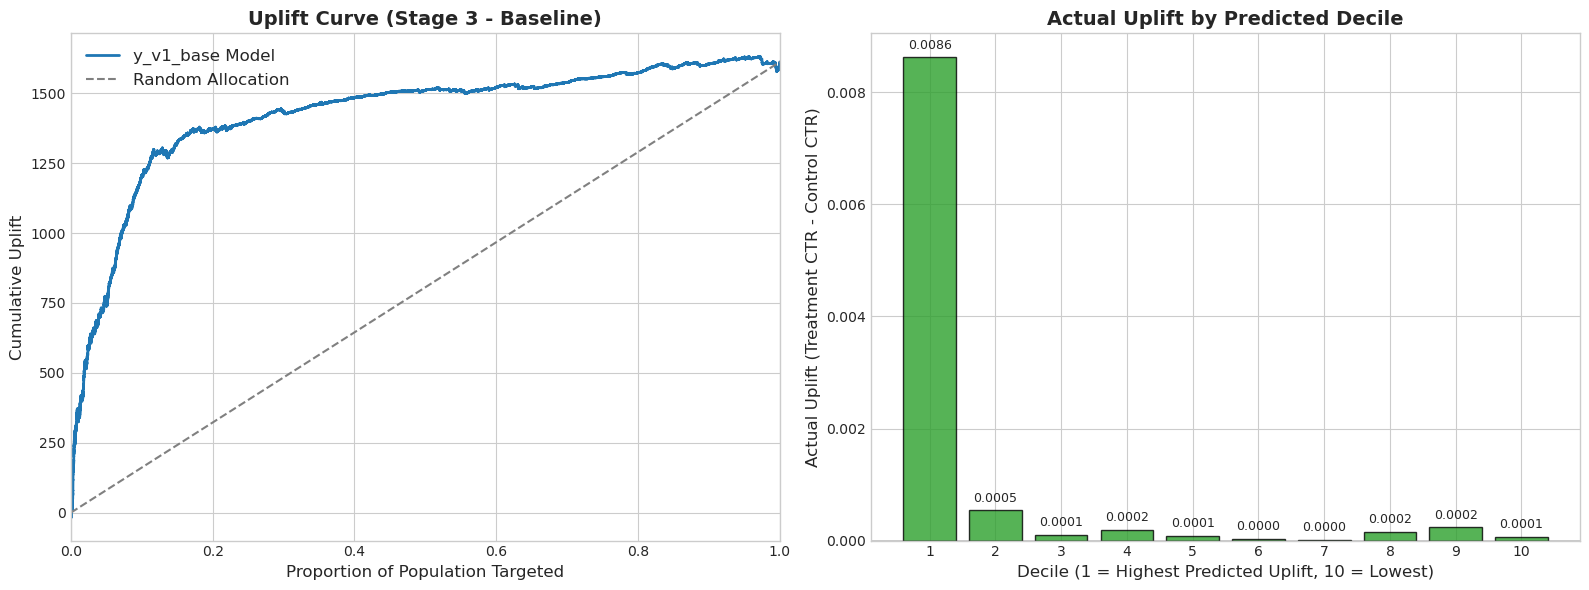

In [8]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. 自动定位 V1 的 test_dist.csv
base_dir = "./results/criteo/train_y/TARNET/y_v1_base"
search_pattern = os.path.join(base_dir, "*", "test_dist.csv")
found_files = glob.glob(search_pattern)

if not found_files:
    print("❌ 找不到 V1 的 test_dist.csv，请检查路径！")
    exit()

csv_path = found_files[0]
print(f"📄 正在读取数据: {csv_path}")
df = pd.read_csv(csv_path)

# 提取关键列
y_true = df['y_true'].values
t = df['t'].values
uplift_pred = df['uplift_pred'].values

# 按预测的 Uplift 降序排列
order = np.argsort(uplift_pred)[::-1]
y_true_sorted = y_true[order]
t_sorted = t[order]

# ==========================================
# 📊 计算 Uplift 曲线数据
# ==========================================
n_t_cum = np.cumsum(t_sorted == 1)
n_c_cum = np.cumsum(t_sorted == 0)
y_t_cum = np.cumsum(y_true_sorted * (t_sorted == 1))
y_c_cum = np.cumsum(y_true_sorted * (t_sorted == 0))

n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)

# 标准 Uplift 曲线公式
uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
x_axis = np.arange(1, len(y_true) + 1) / len(y_true)

# 计算 Random Baseline (终点相连的直线)
total_uplift = uplift_curve[-1]
random_curve = x_axis * total_uplift

# ==========================================
# 📊 计算十分位 (Decile) 柱状图数据
# ==========================================
num_bins = 10
bin_size = len(y_true) // num_bins
decile_uplifts = []

for i in range(num_bins):
    start_idx = i * bin_size
    # 最后一个 bin 把剩下的全包进去
    end_idx = (i + 1) * bin_size if i < num_bins - 1 else len(y_true)
    
    bin_y = y_true_sorted[start_idx:end_idx]
    bin_t = t_sorted[start_idx:end_idx]
    
    cr_t = np.sum(bin_y[bin_t == 1]) / (np.sum(bin_t == 1) + 1e-6)
    cr_c = np.sum(bin_y[bin_t == 0]) / (np.sum(bin_t == 0) + 1e-6)
    
    decile_uplifts.append(cr_t - cr_c)

# ==========================================
# 🎨 开始画图
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid') # 干净的学术风
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 图 1: Uplift Curve
ax1.plot(x_axis, uplift_curve, label='y_v1_base Model', color='#1f77b4', linewidth=2)
ax1.plot(x_axis, random_curve, label='Random Allocation', color='gray', linestyle='--')
ax1.set_title('Uplift Curve (Stage 3 - Baseline)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Proportion of Population Targeted', fontsize=12)
ax1.set_ylabel('Cumulative Uplift', fontsize=12)
ax1.legend(fontsize=12)
ax1.set_xlim([0, 1.0])

# 图 2: Decile Bar Chart
x_bars = np.arange(1, 11)
colors = ['#2ca02c' if val > 0 else '#d62728' for val in decile_uplifts] # 正收益绿色，负收益红色
ax2.bar(x_bars, decile_uplifts, color=colors, alpha=0.8, edgecolor='black')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title('Actual Uplift by Predicted Decile', fontsize=14, fontweight='bold')
ax2.set_xlabel('Decile (1 = Highest Predicted Uplift, 10 = Lowest)', fontsize=12)
ax2.set_ylabel('Actual Uplift (Treatment CTR - Control CTR)', fontsize=12)
ax2.set_xticks(x_bars)

# 添加数值标签
for i, v in enumerate(decile_uplifts):
    ax2.text(i + 1, v + (0.0001 if v > 0 else -0.0003), f"{v:.4f}", 
             ha='center', va='bottom' if v > 0 else 'top', fontsize=9)

plt.tight_layout()
save_path = "v1_baseline_analysis.png"
plt.savefig(save_path, dpi=300)
print(f"\n🎉 画图完成！图片已保存至当前目录的: {save_path}")

📄 正在读取数据: ./results/criteo/train_y/TARNET/y_v1_base/run_v1_base/test_dist.csv

🎉 终极体检报告画图完成！图片已保存至当前目录的: v1_complete_diagnostic.png
👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！


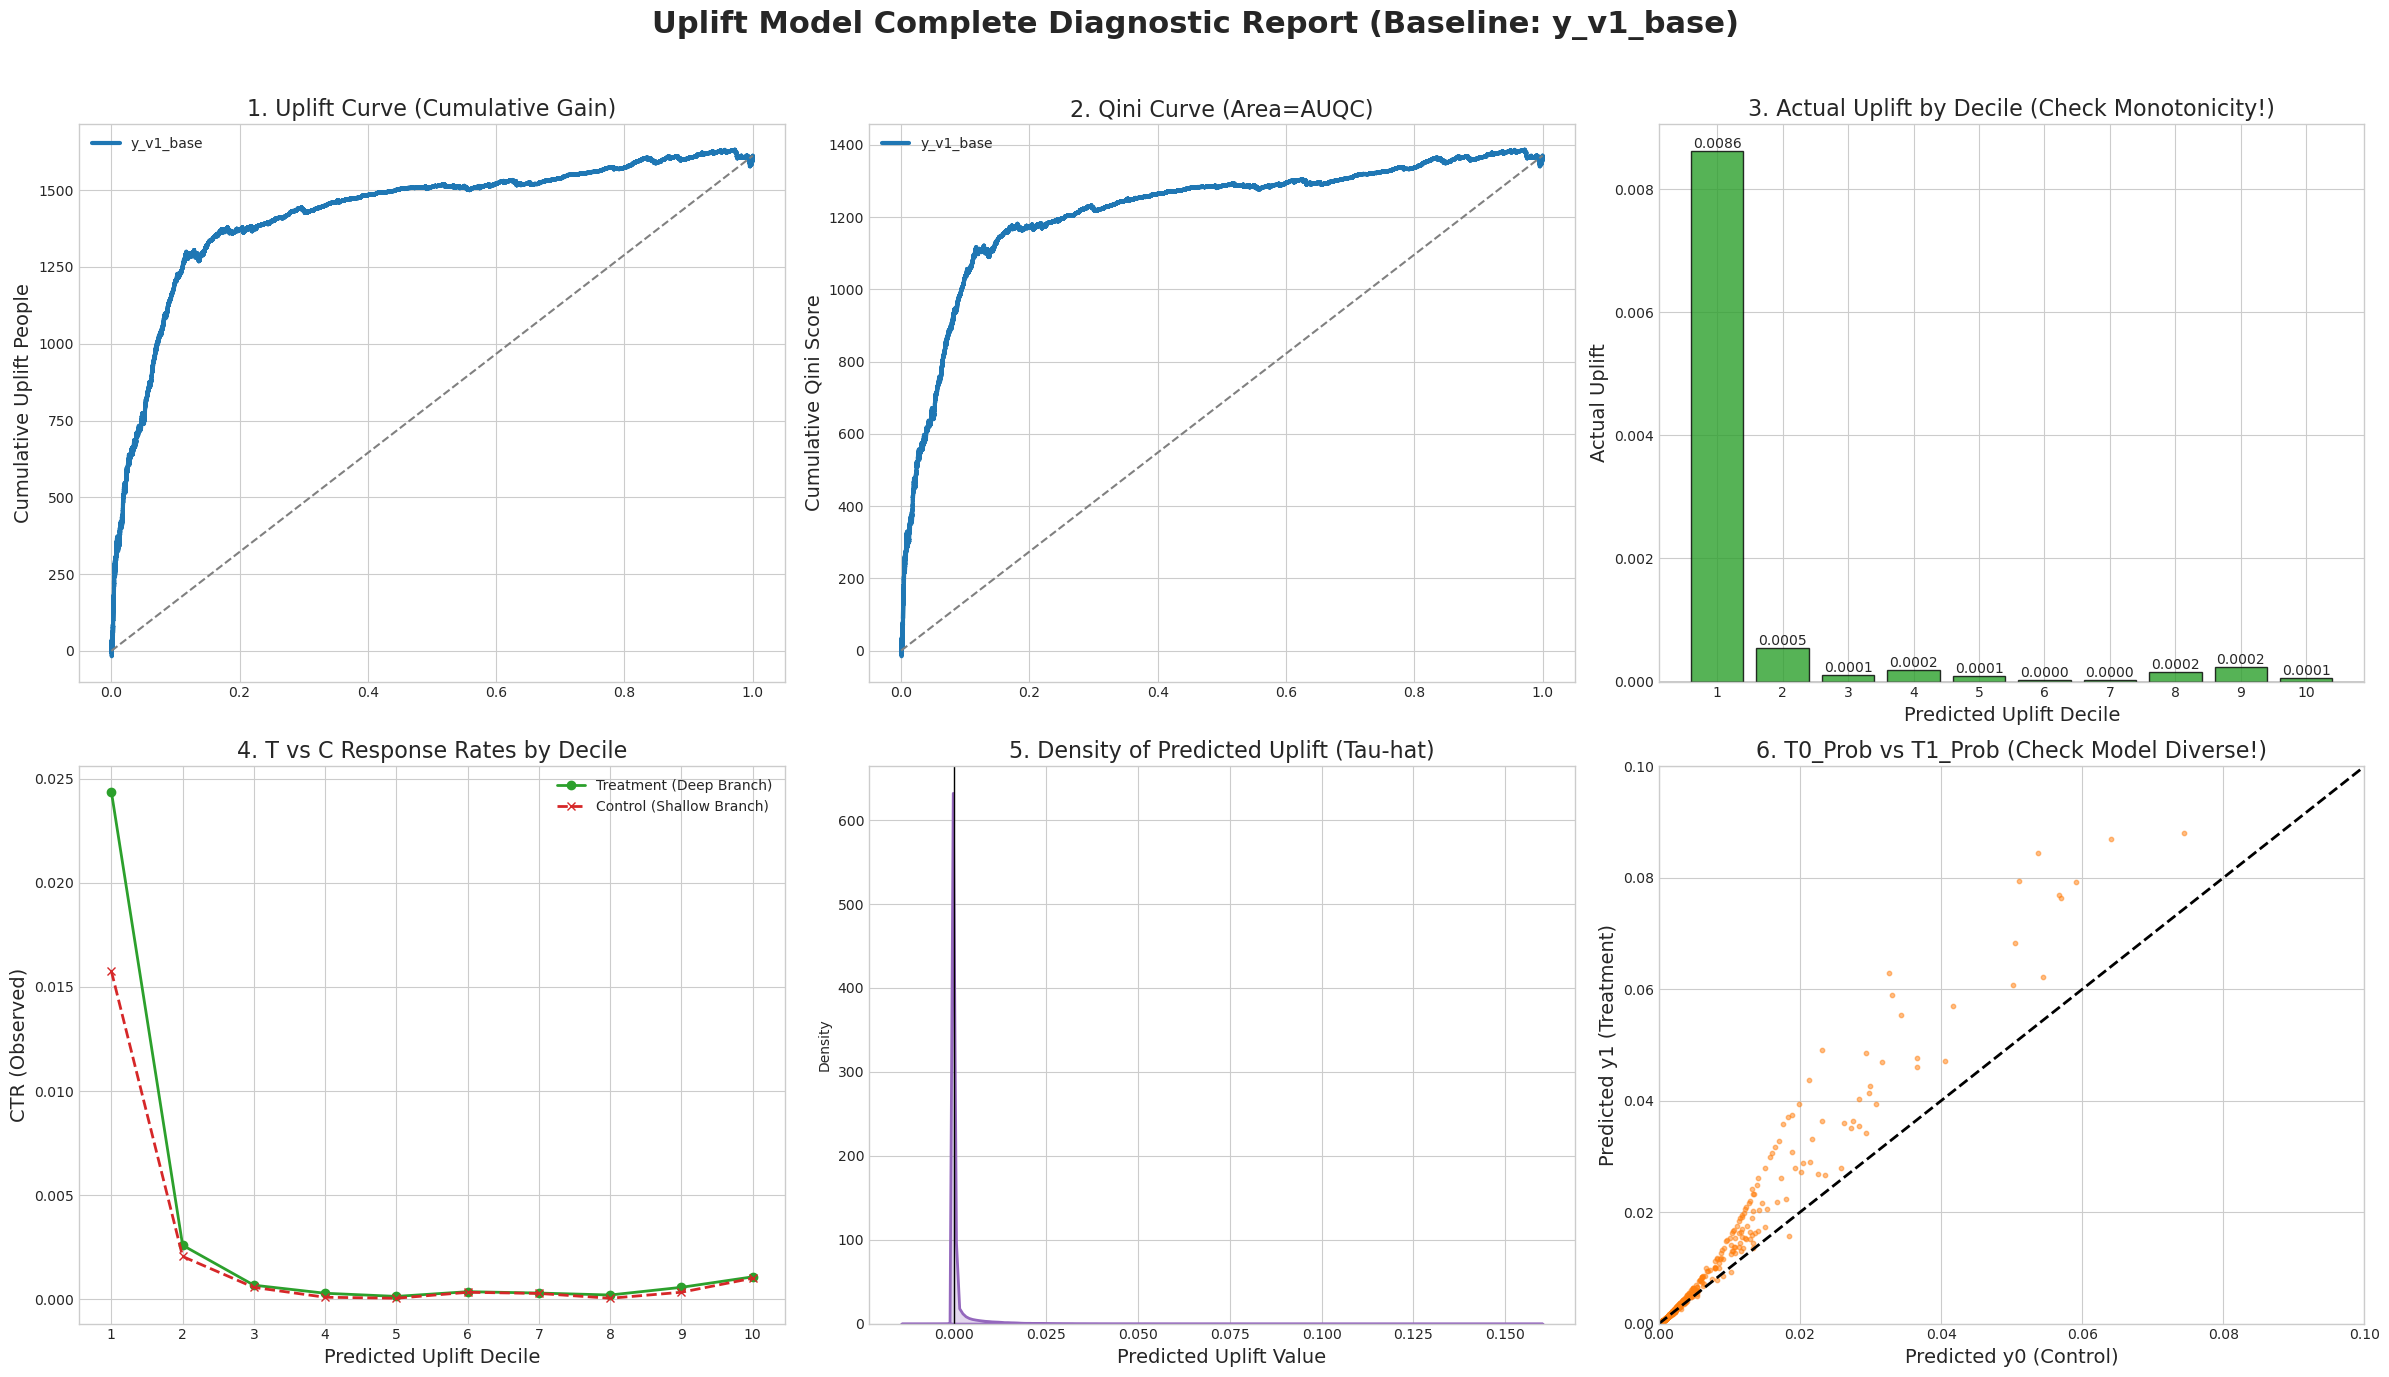

In [9]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 自动定位 V1 的 test_dist.csv
base_dir = "./results/criteo/train_y/TARNET/y_v1_base"
search_pattern = os.path.join(base_dir, "*", "test_dist.csv")
found_files = glob.glob(search_pattern)

if not found_files:
    print("❌ 找不到 V1 的 test_dist.csv，请检查路径！")
    exit()

csv_path = found_files[0]
print(f"📄 正在读取数据: {csv_path}")
df = pd.read_csv(csv_path)

# 提取关键列
y_true = df['y_true'].values
t = df['t'].values
y0_prob = df['y0_prob'].values
y1_prob = df['y1_prob'].values
uplift_pred = df['uplift_pred'].values

# 按预测的 Uplift 降序排列 (用于算曲线和分箱)
order = np.argsort(uplift_pred)[::-1]
y_true_sorted = y_true[order]
t_sorted = t[order]

# ==========================================
# 📊 维度一: 曲线簇 (Curves)
# ==========================================
n_t_cum = np.cumsum(t_sorted == 1)
n_c_cum = np.cumsum(t_sorted == 0)
y_t_cum = np.cumsum(y_true_sorted * (t_sorted == 1))
y_c_cum = np.cumsum(y_true_sorted * (t_sorted == 0))

n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)

# 图 1: Uplift 曲线
uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
x_axis = np.arange(1, len(y_true) + 1) / len(y_true)
# Random baseline
total_uplift = uplift_curve[-1]
random_uplift = x_axis * total_uplift

# 图 2: Qini 曲线
qini_curve = y_t_cum - (y_c_cum * n_t_cum / n_c_safe)
random_qini = x_axis * qini_curve[-1]

# ==========================================
# 📊 维度二: 分箱下钻 (Decile Analysis)
# ==========================================
num_bins = 10
bin_size = len(y_true) // num_bins
decile_uplifts = []
decile_ctrs_t = []
decile_ctrs_c = []

for i in range(num_bins):
    start_idx = i * bin_size
    end_idx = (i + 1) * bin_size if i < num_bins - 1 else len(y_true)
    
    bin_y = y_true_sorted[start_idx:end_idx]
    bin_t = t_sorted[start_idx:end_idx]
    
    cr_t = np.sum(bin_y[bin_t == 1]) / (np.sum(bin_t == 1) + 1e-6)
    cr_c = np.sum(bin_y[bin_t == 0]) / (np.sum(bin_t == 0) + 1e-6)
    
    decile_ctrs_t.append(cr_t)
    decile_ctrs_c.append(cr_c)
    decile_uplifts.append(cr_t - cr_c)

# ==========================================
# 🎨 布局: 终极体检 2x3 布局
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 3, figsize=(24, 14))
plt.suptitle('Uplift Model Complete Diagnostic Report (Baseline: y_v1_base)', fontsize=22, fontweight='bold', y=0.98)

# --- Subplot 1: Uplift Curve ---
axs[0, 0].plot(x_axis, uplift_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 0].plot(x_axis, random_uplift, color='gray', linestyle='--')
axs[0, 0].set_title('1. Uplift Curve (Cumulative Gain)', fontsize=16)
axs[0, 0].set_ylabel('Cumulative Uplift People', fontsize=14)
axs[0, 0].legend()

# --- Subplot 2: Qini Curve ---
axs[0, 1].plot(x_axis, qini_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 1].plot(x_axis, random_qini, color='gray', linestyle='--')
axs[0, 1].set_title('2. Qini Curve (Area=AUQC)', fontsize=16)
axs[0, 1].set_ylabel('Cumulative Qini Score', fontsize=14)
axs[0, 1].legend()

# --- Subplot 3: Uplift by Predicted Decile ---
x_bars = np.arange(1, 11)
colors = ['#2ca02c' if val > 0 else '#d62728' for val in decile_uplifts]
bars = axs[0, 2].bar(x_bars, decile_uplifts, color=colors, alpha=0.8, edgecolor='black')
axs[0, 2].axhline(0, color='black', linewidth=1)
axs[0, 2].set_title('3. Actual Uplift by Decile (Check Monotonicity!)', fontsize=16)
axs[0, 2].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[0, 2].set_xticks(x_bars)
axs[0, 2].set_ylabel('Actual Uplift', fontsize=14)
# 添加数值标签
for bar in bars:
    height = bar.get_height()
    axs[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                   f"{height:.4f}", ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

# --- Subplot 4: T vs C Rate by Decile ---
axs[1, 0].plot(x_bars, decile_ctrs_t, label='Treatment (Deep Branch)', color='#2ca02c', marker='o', linewidth=2)
axs[1, 0].plot(x_bars, decile_ctrs_c, label='Control (Shallow Branch)', color='#d62728', marker='x', linestyle='--', linewidth=2)
axs[1, 0].set_title('4. T vs C Response Rates by Decile', fontsize=16)
axs[1, 0].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[1, 0].set_xticks(x_bars)
axs[1, 0].set_ylabel('CTR (Observed)', fontsize=14)
axs[1, 0].legend()

# --- Subplot 5: Dist of Predicted Uplift (KDE) ---
sns.kdeplot(uplift_pred, ax=axs[1, 1], fill=True, color='#9467bd', linewidth=2)
axs[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axs[1, 1].set_title('5. Density of Predicted Uplift (Tau-hat)', fontsize=16)
axs[1, 1].set_xlabel('Predicted Uplift Value', fontsize=14)

# --- Subplot 6: Twin Tower Scatter Plot ---
# 样本太多，只画 2000 个看分布，否则会卡死且糊成一片
num_scatter = 2000
idx_scatter = np.random.choice(len(y0_prob), num_scatter, replace=False)
axs[1, 2].scatter(y0_prob[idx_scatter], y1_prob[idx_scatter], alpha=0.5, color='#ff7f0e', s=10)
axs[1, 2].plot([0, 0.1], [0, 0.1], color='black', linestyle='--', linewidth=2) # 45度对角线
axs[1, 2].set_title('6. T0_Prob vs T1_Prob (Check Model Diverse!)', fontsize=16)
axs[1, 2].set_xlabel('Predicted y0 (Control)', fontsize=14)
axs[1, 2].set_ylabel('Predicted y1 (Treatment)', fontsize=14)
# Criteo CTR 很低，聚焦坐标轴看细节
axs[1, 2].set_xlim([0, 0.1])
axs[1, 2].set_ylim([0, 0.1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_path = "v1_complete_diagnostic.png"
plt.savefig(save_path, dpi=300)
print(f"\n🎉 终极体检报告画图完成！图片已保存至当前目录的: {save_path}")
print("👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！")

📄 正在读取数据: ./results/criteo/train_y/TARNET/y_v2_emb/run_v2_emb/test_dist.csv

🎉 终极体检报告画图完成！图片已保存至当前目录的: v2_complete_diagnostic.png
👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！


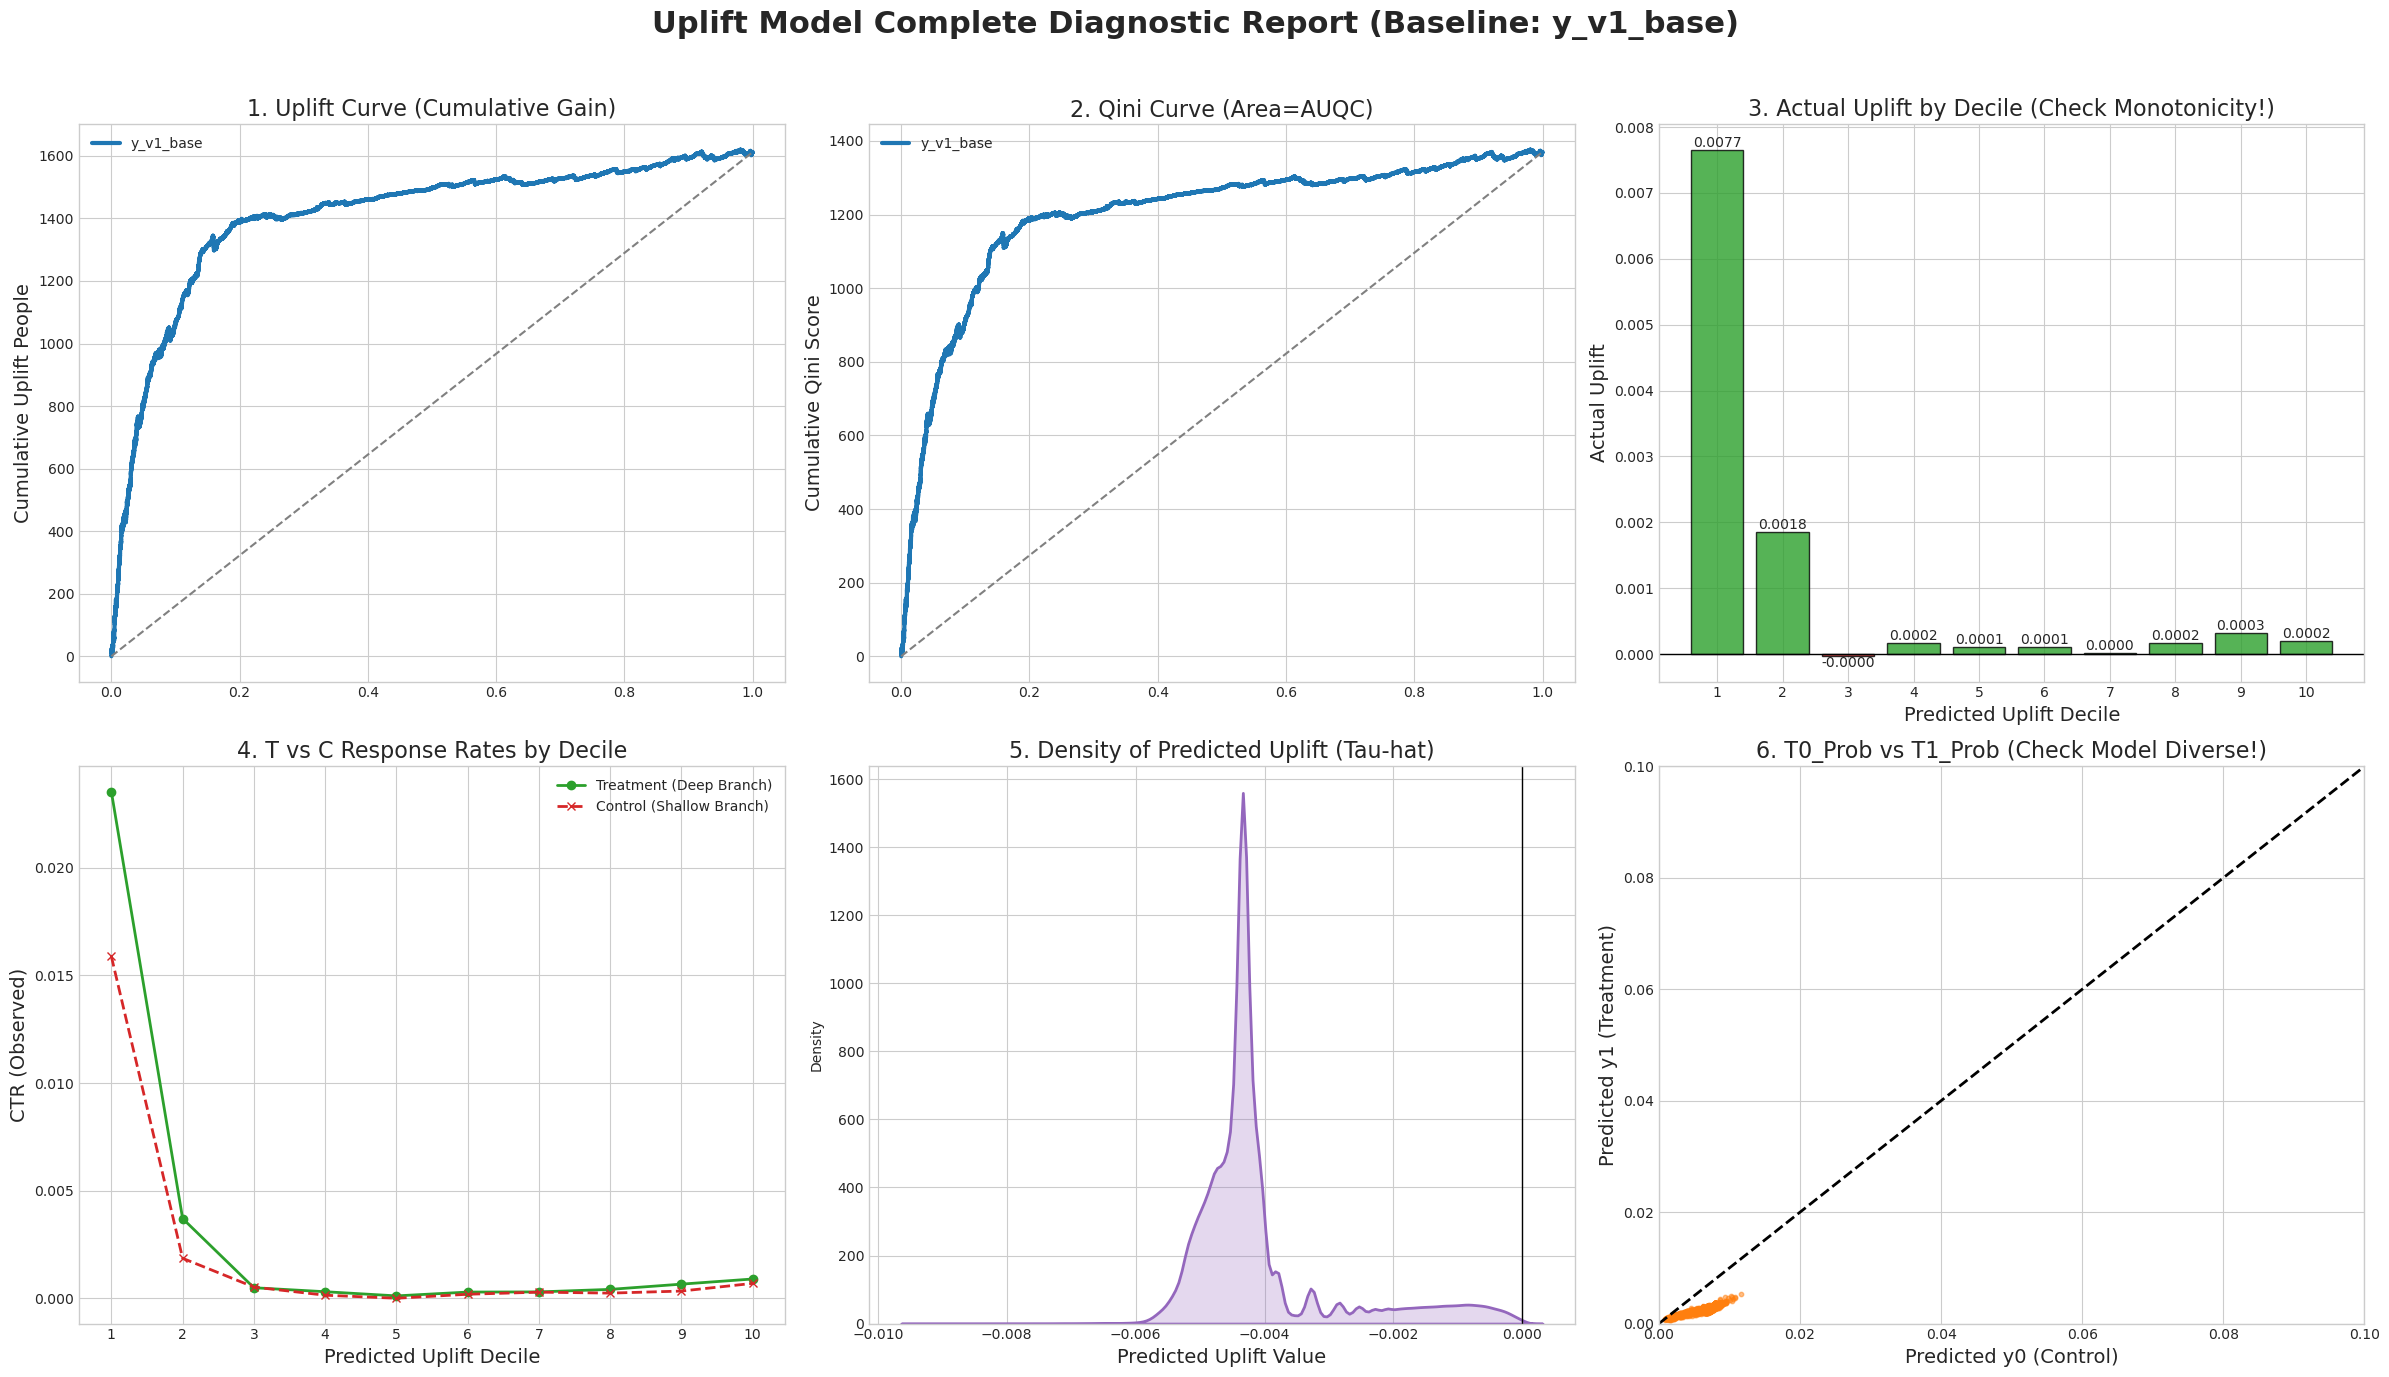

In [10]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 自动定位 V1 的 test_dist.csv
base_dir = "./results/criteo/train_y/TARNET/y_v2_emb"
search_pattern = os.path.join(base_dir, "*", "test_dist.csv")
found_files = glob.glob(search_pattern)

if not found_files:
    print("❌ 找不到 V1 的 test_dist.csv，请检查路径！")
    exit()

csv_path = found_files[0]
print(f"📄 正在读取数据: {csv_path}")
df = pd.read_csv(csv_path)

# 提取关键列
y_true = df['y_true'].values
t = df['t'].values
y0_prob = df['y0_prob'].values
y1_prob = df['y1_prob'].values
uplift_pred = df['uplift_pred'].values

# 按预测的 Uplift 降序排列 (用于算曲线和分箱)
order = np.argsort(uplift_pred)[::-1]
y_true_sorted = y_true[order]
t_sorted = t[order]

# ==========================================
# 📊 维度一: 曲线簇 (Curves)
# ==========================================
n_t_cum = np.cumsum(t_sorted == 1)
n_c_cum = np.cumsum(t_sorted == 0)
y_t_cum = np.cumsum(y_true_sorted * (t_sorted == 1))
y_c_cum = np.cumsum(y_true_sorted * (t_sorted == 0))

n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)

# 图 1: Uplift 曲线
uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
x_axis = np.arange(1, len(y_true) + 1) / len(y_true)
# Random baseline
total_uplift = uplift_curve[-1]
random_uplift = x_axis * total_uplift

# 图 2: Qini 曲线
qini_curve = y_t_cum - (y_c_cum * n_t_cum / n_c_safe)
random_qini = x_axis * qini_curve[-1]

# ==========================================
# 📊 维度二: 分箱下钻 (Decile Analysis)
# ==========================================
num_bins = 10
bin_size = len(y_true) // num_bins
decile_uplifts = []
decile_ctrs_t = []
decile_ctrs_c = []

for i in range(num_bins):
    start_idx = i * bin_size
    end_idx = (i + 1) * bin_size if i < num_bins - 1 else len(y_true)
    
    bin_y = y_true_sorted[start_idx:end_idx]
    bin_t = t_sorted[start_idx:end_idx]
    
    cr_t = np.sum(bin_y[bin_t == 1]) / (np.sum(bin_t == 1) + 1e-6)
    cr_c = np.sum(bin_y[bin_t == 0]) / (np.sum(bin_t == 0) + 1e-6)
    
    decile_ctrs_t.append(cr_t)
    decile_ctrs_c.append(cr_c)
    decile_uplifts.append(cr_t - cr_c)

# ==========================================
# 🎨 布局: 终极体检 2x3 布局
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 3, figsize=(24, 14))
plt.suptitle('Uplift Model Complete Diagnostic Report (Baseline: y_v1_base)', fontsize=22, fontweight='bold', y=0.98)

# --- Subplot 1: Uplift Curve ---
axs[0, 0].plot(x_axis, uplift_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 0].plot(x_axis, random_uplift, color='gray', linestyle='--')
axs[0, 0].set_title('1. Uplift Curve (Cumulative Gain)', fontsize=16)
axs[0, 0].set_ylabel('Cumulative Uplift People', fontsize=14)
axs[0, 0].legend()

# --- Subplot 2: Qini Curve ---
axs[0, 1].plot(x_axis, qini_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 1].plot(x_axis, random_qini, color='gray', linestyle='--')
axs[0, 1].set_title('2. Qini Curve (Area=AUQC)', fontsize=16)
axs[0, 1].set_ylabel('Cumulative Qini Score', fontsize=14)
axs[0, 1].legend()

# --- Subplot 3: Uplift by Predicted Decile ---
x_bars = np.arange(1, 11)
colors = ['#2ca02c' if val > 0 else '#d62728' for val in decile_uplifts]
bars = axs[0, 2].bar(x_bars, decile_uplifts, color=colors, alpha=0.8, edgecolor='black')
axs[0, 2].axhline(0, color='black', linewidth=1)
axs[0, 2].set_title('3. Actual Uplift by Decile (Check Monotonicity!)', fontsize=16)
axs[0, 2].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[0, 2].set_xticks(x_bars)
axs[0, 2].set_ylabel('Actual Uplift', fontsize=14)
# 添加数值标签
for bar in bars:
    height = bar.get_height()
    axs[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                   f"{height:.4f}", ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

# --- Subplot 4: T vs C Rate by Decile ---
axs[1, 0].plot(x_bars, decile_ctrs_t, label='Treatment (Deep Branch)', color='#2ca02c', marker='o', linewidth=2)
axs[1, 0].plot(x_bars, decile_ctrs_c, label='Control (Shallow Branch)', color='#d62728', marker='x', linestyle='--', linewidth=2)
axs[1, 0].set_title('4. T vs C Response Rates by Decile', fontsize=16)
axs[1, 0].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[1, 0].set_xticks(x_bars)
axs[1, 0].set_ylabel('CTR (Observed)', fontsize=14)
axs[1, 0].legend()

# --- Subplot 5: Dist of Predicted Uplift (KDE) ---
sns.kdeplot(uplift_pred, ax=axs[1, 1], fill=True, color='#9467bd', linewidth=2)
axs[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axs[1, 1].set_title('5. Density of Predicted Uplift (Tau-hat)', fontsize=16)
axs[1, 1].set_xlabel('Predicted Uplift Value', fontsize=14)

# --- Subplot 6: Twin Tower Scatter Plot ---
# 样本太多，只画 2000 个看分布，否则会卡死且糊成一片
num_scatter = 2000
idx_scatter = np.random.choice(len(y0_prob), num_scatter, replace=False)
axs[1, 2].scatter(y0_prob[idx_scatter], y1_prob[idx_scatter], alpha=0.5, color='#ff7f0e', s=10)
axs[1, 2].plot([0, 0.1], [0, 0.1], color='black', linestyle='--', linewidth=2) # 45度对角线
axs[1, 2].set_title('6. T0_Prob vs T1_Prob (Check Model Diverse!)', fontsize=16)
axs[1, 2].set_xlabel('Predicted y0 (Control)', fontsize=14)
axs[1, 2].set_ylabel('Predicted y1 (Treatment)', fontsize=14)
# Criteo CTR 很低，聚焦坐标轴看细节
axs[1, 2].set_xlim([0, 0.1])
axs[1, 2].set_ylim([0, 0.1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_path = "v2_complete_diagnostic.png"
plt.savefig(save_path, dpi=300)
print(f"\n🎉 终极体检报告画图完成！图片已保存至当前目录的: {save_path}")
print("👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！")

📄 正在读取数据: ./results/criteo/train_y/TARNET/y_v5_loss_var/run_v5_var/test_dist.csv

🎉 终极体检报告画图完成！图片已保存至当前目录的: v5_complete_diagnostic.png
👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！


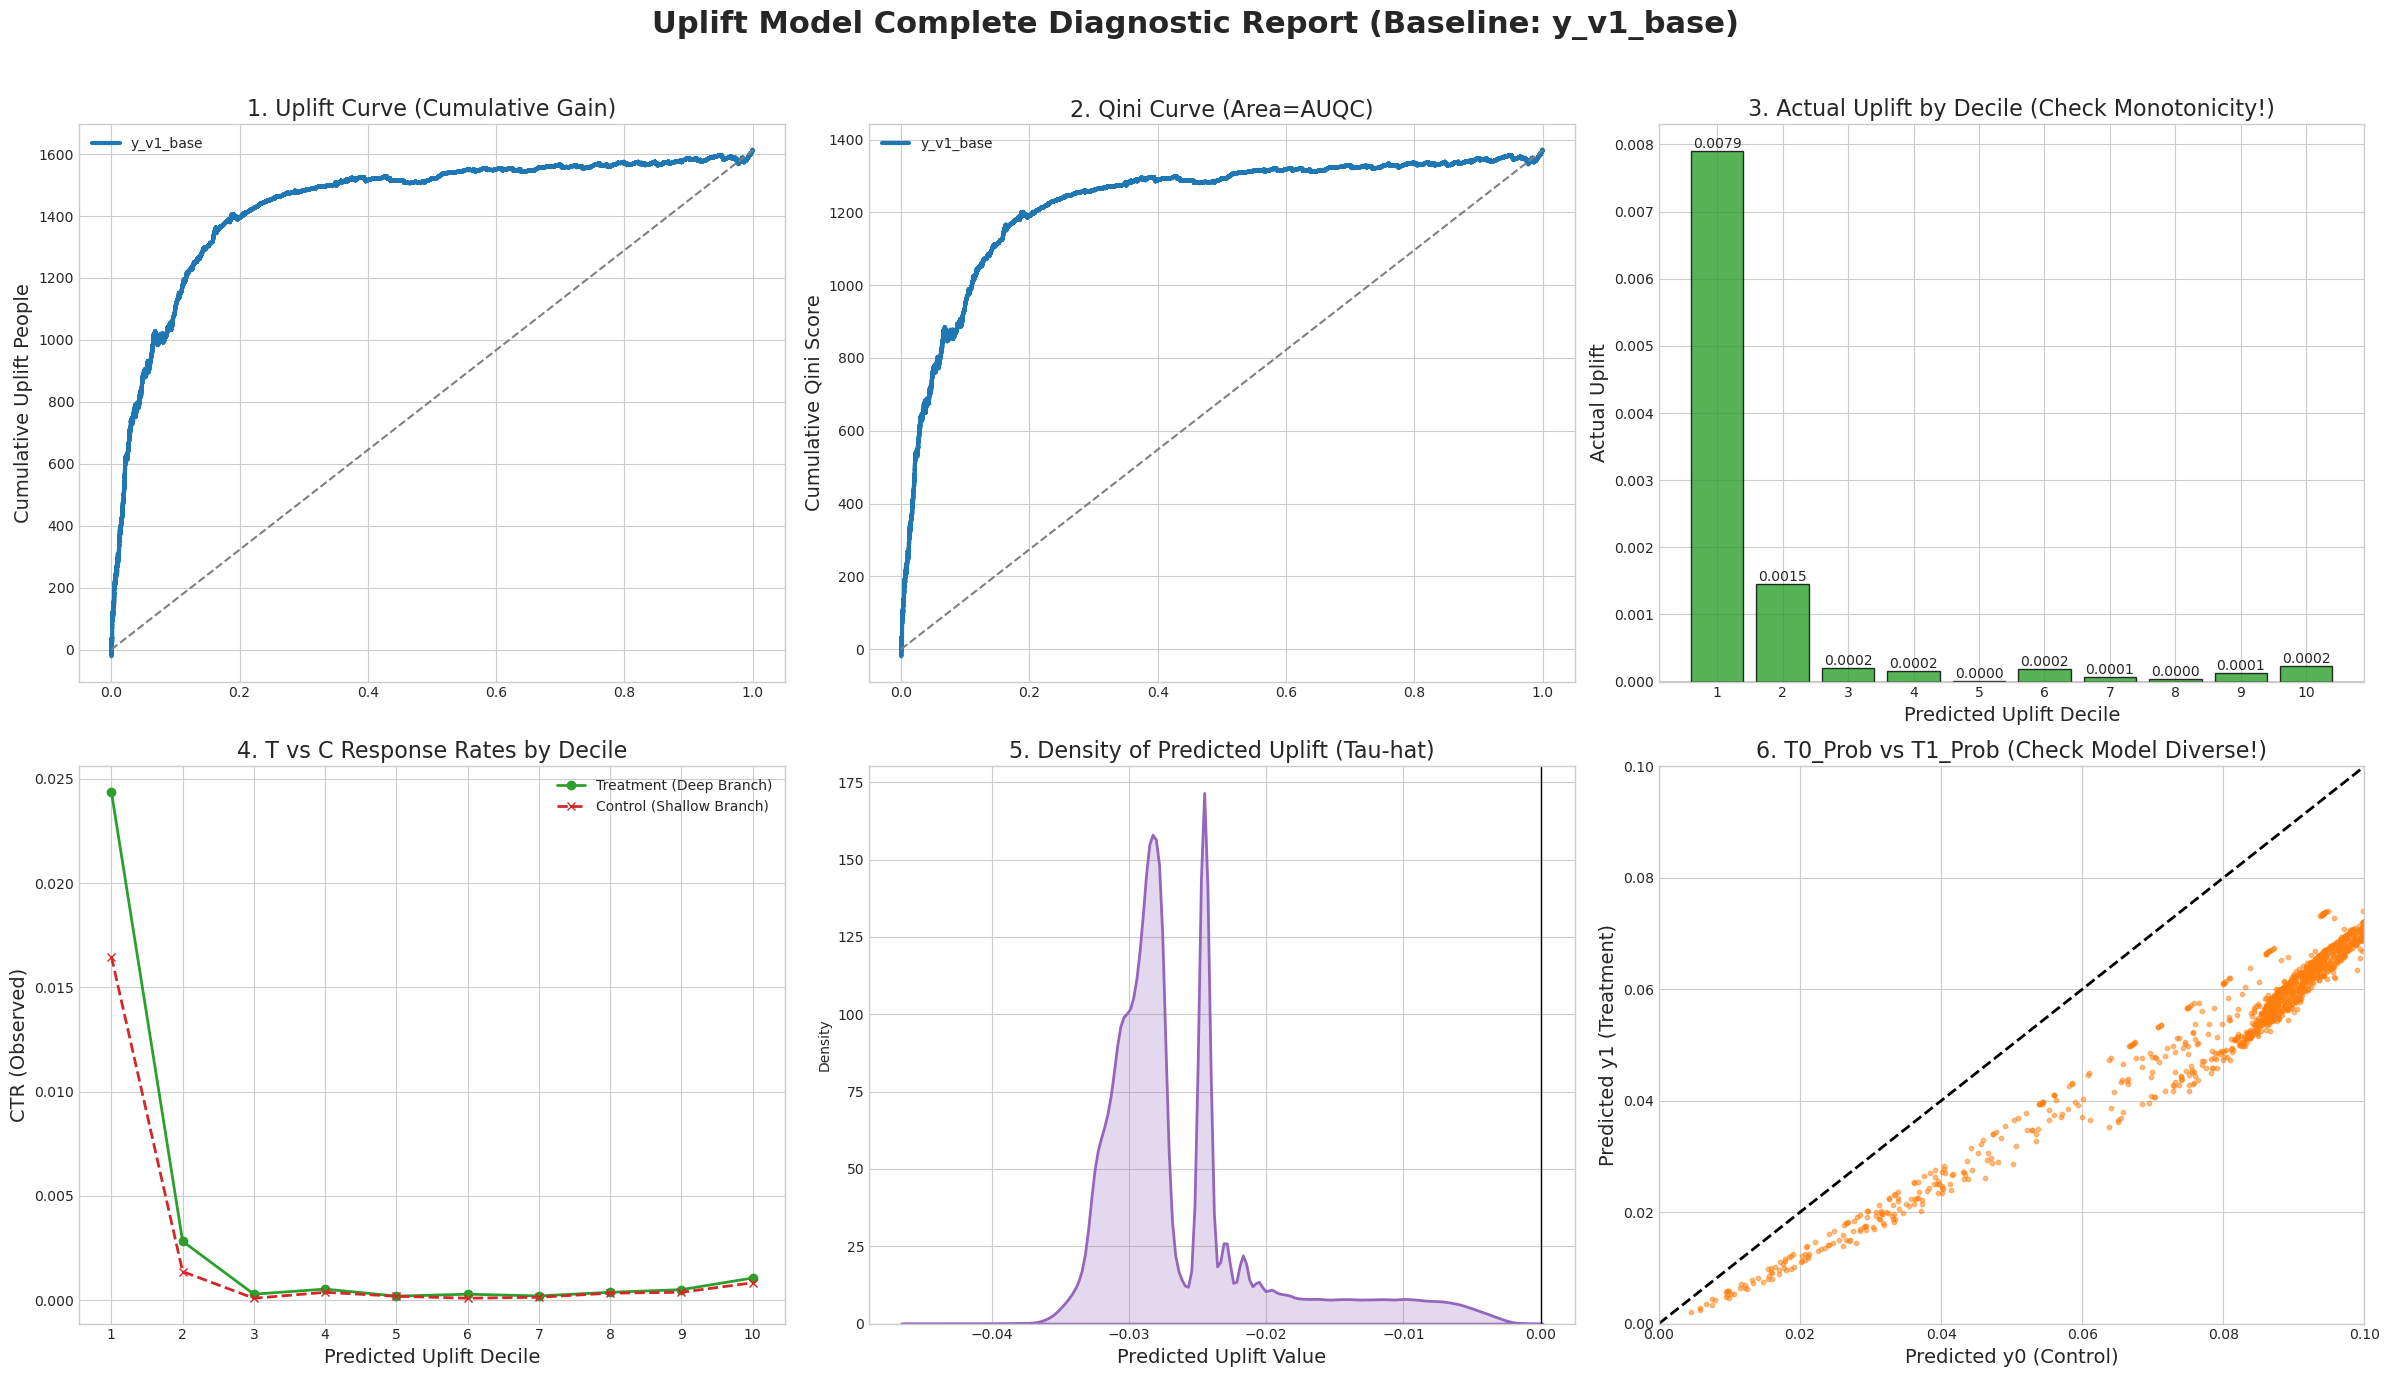

In [11]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 自动定位 V1 的 test_dist.csv
base_dir = "./results/criteo/train_y/TARNET/y_v5_loss_var"
search_pattern = os.path.join(base_dir, "*", "test_dist.csv")
found_files = glob.glob(search_pattern)

if not found_files:
    print("❌ 找不到 V1 的 test_dist.csv，请检查路径！")
    exit()

csv_path = found_files[0]
print(f"📄 正在读取数据: {csv_path}")
df = pd.read_csv(csv_path)

# 提取关键列
y_true = df['y_true'].values
t = df['t'].values
y0_prob = df['y0_prob'].values
y1_prob = df['y1_prob'].values
uplift_pred = df['uplift_pred'].values

# 按预测的 Uplift 降序排列 (用于算曲线和分箱)
order = np.argsort(uplift_pred)[::-1]
y_true_sorted = y_true[order]
t_sorted = t[order]

# ==========================================
# 📊 维度一: 曲线簇 (Curves)
# ==========================================
n_t_cum = np.cumsum(t_sorted == 1)
n_c_cum = np.cumsum(t_sorted == 0)
y_t_cum = np.cumsum(y_true_sorted * (t_sorted == 1))
y_c_cum = np.cumsum(y_true_sorted * (t_sorted == 0))

n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)

# 图 1: Uplift 曲线
uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
x_axis = np.arange(1, len(y_true) + 1) / len(y_true)
# Random baseline
total_uplift = uplift_curve[-1]
random_uplift = x_axis * total_uplift

# 图 2: Qini 曲线
qini_curve = y_t_cum - (y_c_cum * n_t_cum / n_c_safe)
random_qini = x_axis * qini_curve[-1]

# ==========================================
# 📊 维度二: 分箱下钻 (Decile Analysis)
# ==========================================
num_bins = 10
bin_size = len(y_true) // num_bins
decile_uplifts = []
decile_ctrs_t = []
decile_ctrs_c = []

for i in range(num_bins):
    start_idx = i * bin_size
    end_idx = (i + 1) * bin_size if i < num_bins - 1 else len(y_true)
    
    bin_y = y_true_sorted[start_idx:end_idx]
    bin_t = t_sorted[start_idx:end_idx]
    
    cr_t = np.sum(bin_y[bin_t == 1]) / (np.sum(bin_t == 1) + 1e-6)
    cr_c = np.sum(bin_y[bin_t == 0]) / (np.sum(bin_t == 0) + 1e-6)
    
    decile_ctrs_t.append(cr_t)
    decile_ctrs_c.append(cr_c)
    decile_uplifts.append(cr_t - cr_c)

# ==========================================
# 🎨 布局: 终极体检 2x3 布局
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 3, figsize=(24, 14))
plt.suptitle('Uplift Model Complete Diagnostic Report (Baseline: y_v1_base)', fontsize=22, fontweight='bold', y=0.98)

# --- Subplot 1: Uplift Curve ---
axs[0, 0].plot(x_axis, uplift_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 0].plot(x_axis, random_uplift, color='gray', linestyle='--')
axs[0, 0].set_title('1. Uplift Curve (Cumulative Gain)', fontsize=16)
axs[0, 0].set_ylabel('Cumulative Uplift People', fontsize=14)
axs[0, 0].legend()

# --- Subplot 2: Qini Curve ---
axs[0, 1].plot(x_axis, qini_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 1].plot(x_axis, random_qini, color='gray', linestyle='--')
axs[0, 1].set_title('2. Qini Curve (Area=AUQC)', fontsize=16)
axs[0, 1].set_ylabel('Cumulative Qini Score', fontsize=14)
axs[0, 1].legend()

# --- Subplot 3: Uplift by Predicted Decile ---
x_bars = np.arange(1, 11)
colors = ['#2ca02c' if val > 0 else '#d62728' for val in decile_uplifts]
bars = axs[0, 2].bar(x_bars, decile_uplifts, color=colors, alpha=0.8, edgecolor='black')
axs[0, 2].axhline(0, color='black', linewidth=1)
axs[0, 2].set_title('3. Actual Uplift by Decile (Check Monotonicity!)', fontsize=16)
axs[0, 2].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[0, 2].set_xticks(x_bars)
axs[0, 2].set_ylabel('Actual Uplift', fontsize=14)
# 添加数值标签
for bar in bars:
    height = bar.get_height()
    axs[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                   f"{height:.4f}", ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

# --- Subplot 4: T vs C Rate by Decile ---
axs[1, 0].plot(x_bars, decile_ctrs_t, label='Treatment (Deep Branch)', color='#2ca02c', marker='o', linewidth=2)
axs[1, 0].plot(x_bars, decile_ctrs_c, label='Control (Shallow Branch)', color='#d62728', marker='x', linestyle='--', linewidth=2)
axs[1, 0].set_title('4. T vs C Response Rates by Decile', fontsize=16)
axs[1, 0].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[1, 0].set_xticks(x_bars)
axs[1, 0].set_ylabel('CTR (Observed)', fontsize=14)
axs[1, 0].legend()

# --- Subplot 5: Dist of Predicted Uplift (KDE) ---
sns.kdeplot(uplift_pred, ax=axs[1, 1], fill=True, color='#9467bd', linewidth=2)
axs[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axs[1, 1].set_title('5. Density of Predicted Uplift (Tau-hat)', fontsize=16)
axs[1, 1].set_xlabel('Predicted Uplift Value', fontsize=14)

# --- Subplot 6: Twin Tower Scatter Plot ---
# 样本太多，只画 2000 个看分布，否则会卡死且糊成一片
num_scatter = 2000
idx_scatter = np.random.choice(len(y0_prob), num_scatter, replace=False)
axs[1, 2].scatter(y0_prob[idx_scatter], y1_prob[idx_scatter], alpha=0.5, color='#ff7f0e', s=10)
axs[1, 2].plot([0, 0.1], [0, 0.1], color='black', linestyle='--', linewidth=2) # 45度对角线
axs[1, 2].set_title('6. T0_Prob vs T1_Prob (Check Model Diverse!)', fontsize=16)
axs[1, 2].set_xlabel('Predicted y0 (Control)', fontsize=14)
axs[1, 2].set_ylabel('Predicted y1 (Treatment)', fontsize=14)
# Criteo CTR 很低，聚焦坐标轴看细节
axs[1, 2].set_xlim([0, 0.1])
axs[1, 2].set_ylim([0, 0.1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_path = "v5_complete_diagnostic.png"
plt.savefig(save_path, dpi=300)
print(f"\n🎉 终极体检报告画图完成！图片已保存至当前目录的: {save_path}")
print("👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！")

📄 正在读取数据: ./results/criteo/train_y/TARNET/y_v5_loss_var/run_v5_var/test_dist.csv

🎉 终极体检报告画图完成！图片已保存至当前目录的: v5_complete_diagnostic.png
👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！


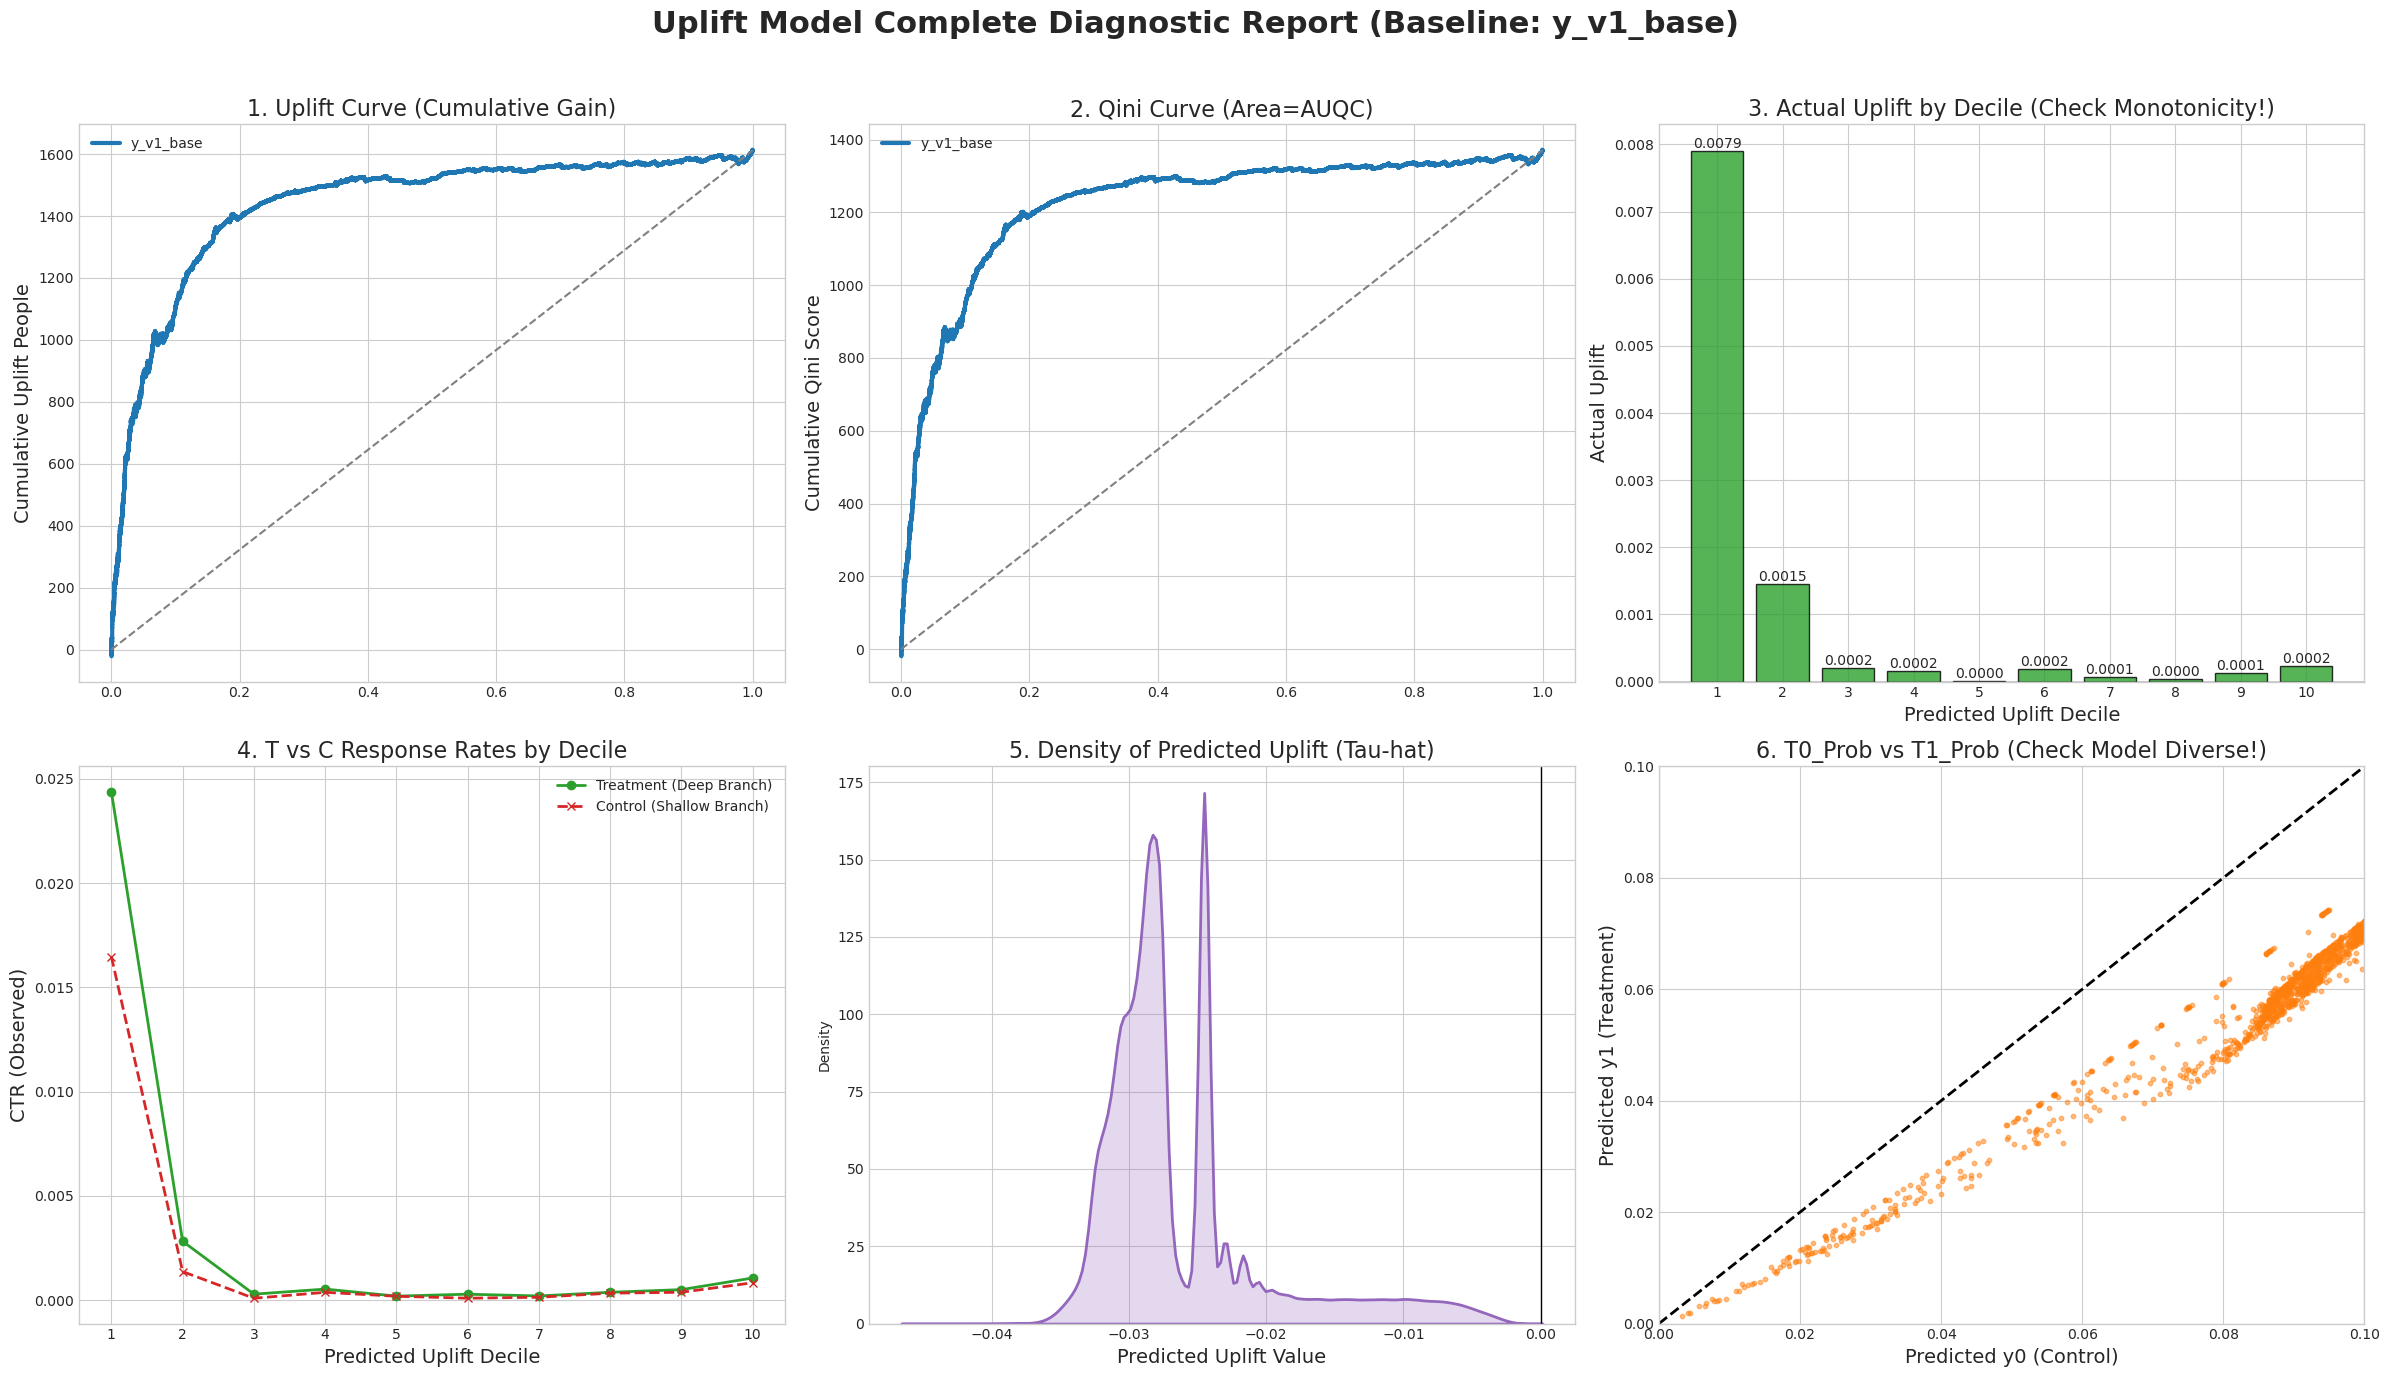

In [12]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 自动定位 V1 的 test_dist.csv
base_dir = "./results/criteo/train_y/TARNET/y_v5_loss_var"
search_pattern = os.path.join(base_dir, "*", "test_dist.csv")
found_files = glob.glob(search_pattern)

if not found_files:
    print("❌ 找不到 V1 的 test_dist.csv，请检查路径！")
    exit()

csv_path = found_files[0]
print(f"📄 正在读取数据: {csv_path}")
df = pd.read_csv(csv_path)

# 提取关键列
y_true = df['y_true'].values
t = df['t'].values
y0_prob = df['y0_prob'].values
y1_prob = df['y1_prob'].values
uplift_pred = df['uplift_pred'].values

# 按预测的 Uplift 降序排列 (用于算曲线和分箱)
order = np.argsort(uplift_pred)[::-1]
y_true_sorted = y_true[order]
t_sorted = t[order]

# ==========================================
# 📊 维度一: 曲线簇 (Curves)
# ==========================================
n_t_cum = np.cumsum(t_sorted == 1)
n_c_cum = np.cumsum(t_sorted == 0)
y_t_cum = np.cumsum(y_true_sorted * (t_sorted == 1))
y_c_cum = np.cumsum(y_true_sorted * (t_sorted == 0))

n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)

# 图 1: Uplift 曲线
uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
x_axis = np.arange(1, len(y_true) + 1) / len(y_true)
# Random baseline
total_uplift = uplift_curve[-1]
random_uplift = x_axis * total_uplift

# 图 2: Qini 曲线
qini_curve = y_t_cum - (y_c_cum * n_t_cum / n_c_safe)
random_qini = x_axis * qini_curve[-1]

# ==========================================
# 📊 维度二: 分箱下钻 (Decile Analysis)
# ==========================================
num_bins = 10
bin_size = len(y_true) // num_bins
decile_uplifts = []
decile_ctrs_t = []
decile_ctrs_c = []

for i in range(num_bins):
    start_idx = i * bin_size
    end_idx = (i + 1) * bin_size if i < num_bins - 1 else len(y_true)
    
    bin_y = y_true_sorted[start_idx:end_idx]
    bin_t = t_sorted[start_idx:end_idx]
    
    cr_t = np.sum(bin_y[bin_t == 1]) / (np.sum(bin_t == 1) + 1e-6)
    cr_c = np.sum(bin_y[bin_t == 0]) / (np.sum(bin_t == 0) + 1e-6)
    
    decile_ctrs_t.append(cr_t)
    decile_ctrs_c.append(cr_c)
    decile_uplifts.append(cr_t - cr_c)

# ==========================================
# 🎨 布局: 终极体检 2x3 布局
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 3, figsize=(24, 14))
plt.suptitle('Uplift Model Complete Diagnostic Report (Baseline: y_v1_base)', fontsize=22, fontweight='bold', y=0.98)

# --- Subplot 1: Uplift Curve ---
axs[0, 0].plot(x_axis, uplift_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 0].plot(x_axis, random_uplift, color='gray', linestyle='--')
axs[0, 0].set_title('1. Uplift Curve (Cumulative Gain)', fontsize=16)
axs[0, 0].set_ylabel('Cumulative Uplift People', fontsize=14)
axs[0, 0].legend()

# --- Subplot 2: Qini Curve ---
axs[0, 1].plot(x_axis, qini_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 1].plot(x_axis, random_qini, color='gray', linestyle='--')
axs[0, 1].set_title('2. Qini Curve (Area=AUQC)', fontsize=16)
axs[0, 1].set_ylabel('Cumulative Qini Score', fontsize=14)
axs[0, 1].legend()

# --- Subplot 3: Uplift by Predicted Decile ---
x_bars = np.arange(1, 11)
colors = ['#2ca02c' if val > 0 else '#d62728' for val in decile_uplifts]
bars = axs[0, 2].bar(x_bars, decile_uplifts, color=colors, alpha=0.8, edgecolor='black')
axs[0, 2].axhline(0, color='black', linewidth=1)
axs[0, 2].set_title('3. Actual Uplift by Decile (Check Monotonicity!)', fontsize=16)
axs[0, 2].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[0, 2].set_xticks(x_bars)
axs[0, 2].set_ylabel('Actual Uplift', fontsize=14)
# 添加数值标签
for bar in bars:
    height = bar.get_height()
    axs[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                   f"{height:.4f}", ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

# --- Subplot 4: T vs C Rate by Decile ---
axs[1, 0].plot(x_bars, decile_ctrs_t, label='Treatment (Deep Branch)', color='#2ca02c', marker='o', linewidth=2)
axs[1, 0].plot(x_bars, decile_ctrs_c, label='Control (Shallow Branch)', color='#d62728', marker='x', linestyle='--', linewidth=2)
axs[1, 0].set_title('4. T vs C Response Rates by Decile', fontsize=16)
axs[1, 0].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[1, 0].set_xticks(x_bars)
axs[1, 0].set_ylabel('CTR (Observed)', fontsize=14)
axs[1, 0].legend()

# --- Subplot 5: Dist of Predicted Uplift (KDE) ---
sns.kdeplot(uplift_pred, ax=axs[1, 1], fill=True, color='#9467bd', linewidth=2)
axs[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axs[1, 1].set_title('5. Density of Predicted Uplift (Tau-hat)', fontsize=16)
axs[1, 1].set_xlabel('Predicted Uplift Value', fontsize=14)

# --- Subplot 6: Twin Tower Scatter Plot ---
# 样本太多，只画 2000 个看分布，否则会卡死且糊成一片
num_scatter = 2000
idx_scatter = np.random.choice(len(y0_prob), num_scatter, replace=False)
axs[1, 2].scatter(y0_prob[idx_scatter], y1_prob[idx_scatter], alpha=0.5, color='#ff7f0e', s=10)
axs[1, 2].plot([0, 0.1], [0, 0.1], color='black', linestyle='--', linewidth=2) # 45度对角线
axs[1, 2].set_title('6. T0_Prob vs T1_Prob (Check Model Diverse!)', fontsize=16)
axs[1, 2].set_xlabel('Predicted y0 (Control)', fontsize=14)
axs[1, 2].set_ylabel('Predicted y1 (Treatment)', fontsize=14)
# Criteo CTR 很低，聚焦坐标轴看细节
axs[1, 2].set_xlim([0, 0.1])
axs[1, 2].set_ylim([0, 0.1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_path = "v5_complete_diagnostic.png"
plt.savefig(save_path, dpi=300)
print(f"\n🎉 终极体检报告画图完成！图片已保存至当前目录的: {save_path}")
print("👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！")

📄 正在读取数据: ./results/criteo/train_y/TARNET/y_v5_loss_var/run_v5_var/test_dist.csv

🎉 终极体检报告画图完成！图片已保存至当前目录的: v5_complete_diagnostic.png
👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！


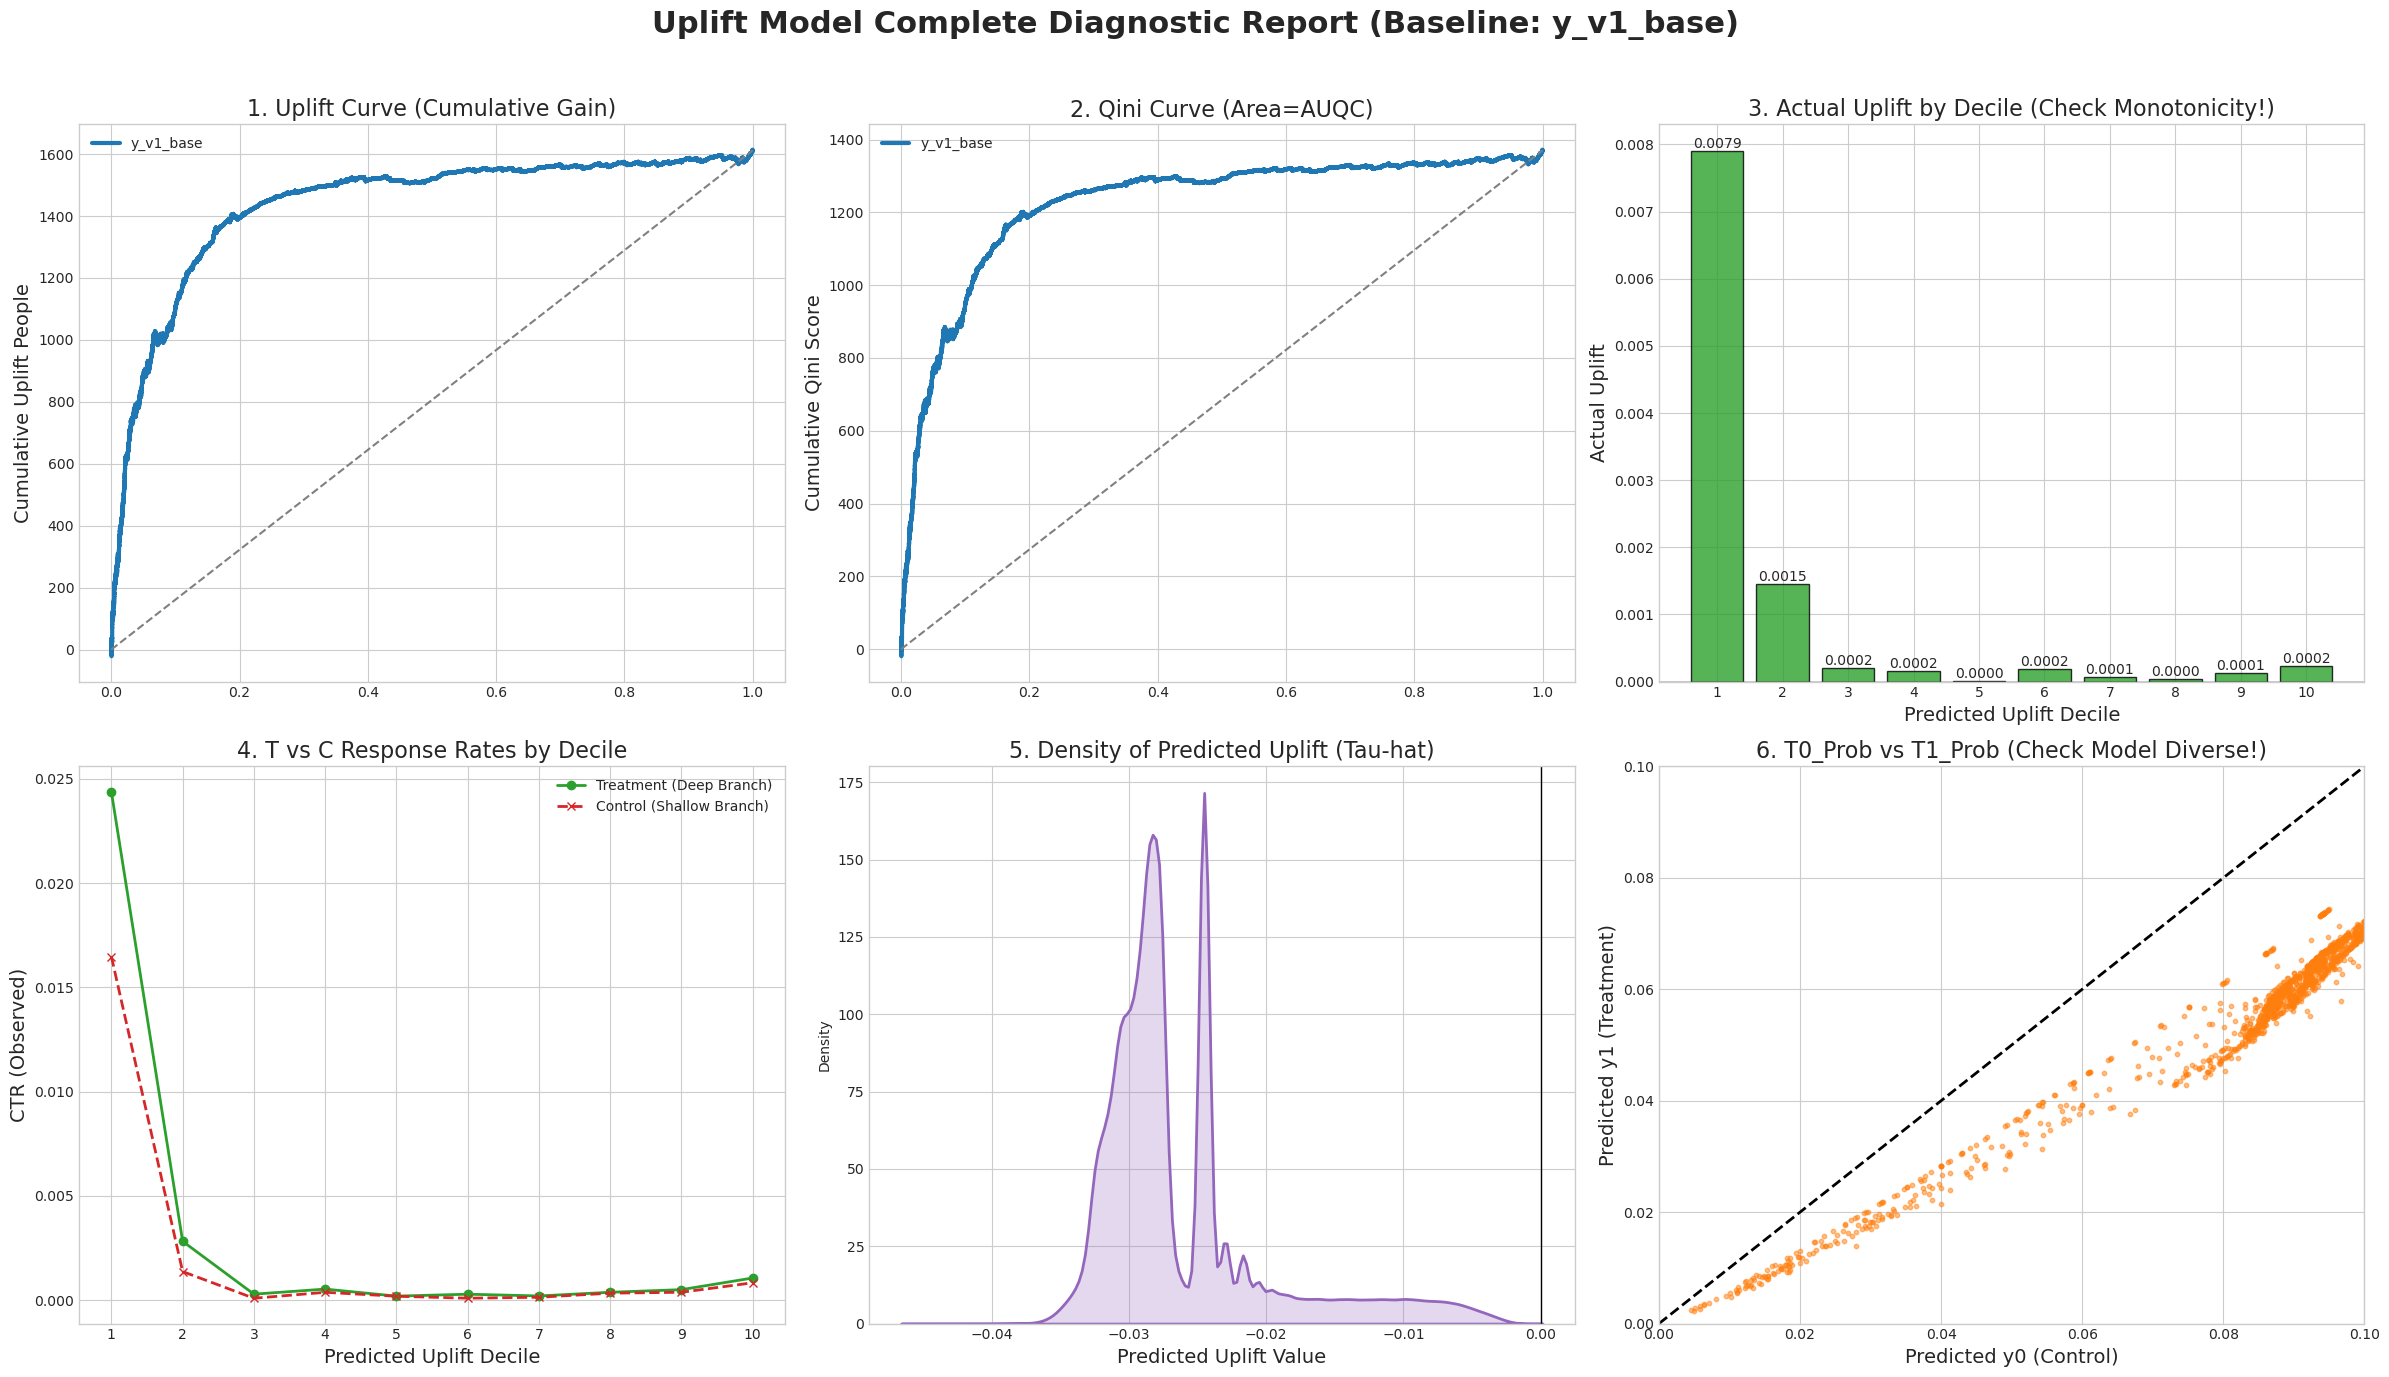

In [13]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 自动定位 V1 的 test_dist.csv
base_dir = "./results/criteo/train_y/TARNET/y_v5_loss_var"
search_pattern = os.path.join(base_dir, "*", "test_dist.csv")
found_files = glob.glob(search_pattern)

if not found_files:
    print("❌ 找不到 V1 的 test_dist.csv，请检查路径！")
    exit()

csv_path = found_files[0]
print(f"📄 正在读取数据: {csv_path}")
df = pd.read_csv(csv_path)

# 提取关键列
y_true = df['y_true'].values
t = df['t'].values
y0_prob = df['y0_prob'].values
y1_prob = df['y1_prob'].values
uplift_pred = df['uplift_pred'].values

# 按预测的 Uplift 降序排列 (用于算曲线和分箱)
order = np.argsort(uplift_pred)[::-1]
y_true_sorted = y_true[order]
t_sorted = t[order]

# ==========================================
# 📊 维度一: 曲线簇 (Curves)
# ==========================================
n_t_cum = np.cumsum(t_sorted == 1)
n_c_cum = np.cumsum(t_sorted == 0)
y_t_cum = np.cumsum(y_true_sorted * (t_sorted == 1))
y_c_cum = np.cumsum(y_true_sorted * (t_sorted == 0))

n_t_safe = np.where(n_t_cum == 0, 1e-6, n_t_cum)
n_c_safe = np.where(n_c_cum == 0, 1e-6, n_c_cum)

# 图 1: Uplift 曲线
uplift_curve = (y_t_cum / n_t_safe - y_c_cum / n_c_safe) * (n_t_cum + n_c_cum)
x_axis = np.arange(1, len(y_true) + 1) / len(y_true)
# Random baseline
total_uplift = uplift_curve[-1]
random_uplift = x_axis * total_uplift

# 图 2: Qini 曲线
qini_curve = y_t_cum - (y_c_cum * n_t_cum / n_c_safe)
random_qini = x_axis * qini_curve[-1]

# ==========================================
# 📊 维度二: 分箱下钻 (Decile Analysis)
# ==========================================
num_bins = 10
bin_size = len(y_true) // num_bins
decile_uplifts = []
decile_ctrs_t = []
decile_ctrs_c = []

for i in range(num_bins):
    start_idx = i * bin_size
    end_idx = (i + 1) * bin_size if i < num_bins - 1 else len(y_true)
    
    bin_y = y_true_sorted[start_idx:end_idx]
    bin_t = t_sorted[start_idx:end_idx]
    
    cr_t = np.sum(bin_y[bin_t == 1]) / (np.sum(bin_t == 1) + 1e-6)
    cr_c = np.sum(bin_y[bin_t == 0]) / (np.sum(bin_t == 0) + 1e-6)
    
    decile_ctrs_t.append(cr_t)
    decile_ctrs_c.append(cr_c)
    decile_uplifts.append(cr_t - cr_c)

# ==========================================
# 🎨 布局: 终极体检 2x3 布局
# ==========================================
plt.style.use('seaborn-v0_8-whitegrid')
fig, axs = plt.subplots(2, 3, figsize=(24, 14))
plt.suptitle('Uplift Model Complete Diagnostic Report (Baseline: y_v1_base)', fontsize=22, fontweight='bold', y=0.98)

# --- Subplot 1: Uplift Curve ---
axs[0, 0].plot(x_axis, uplift_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 0].plot(x_axis, random_uplift, color='gray', linestyle='--')
axs[0, 0].set_title('1. Uplift Curve (Cumulative Gain)', fontsize=16)
axs[0, 0].set_ylabel('Cumulative Uplift People', fontsize=14)
axs[0, 0].legend()

# --- Subplot 2: Qini Curve ---
axs[0, 1].plot(x_axis, qini_curve, label='y_v1_base', color='#1f77b4', linewidth=3)
axs[0, 1].plot(x_axis, random_qini, color='gray', linestyle='--')
axs[0, 1].set_title('2. Qini Curve (Area=AUQC)', fontsize=16)
axs[0, 1].set_ylabel('Cumulative Qini Score', fontsize=14)
axs[0, 1].legend()

# --- Subplot 3: Uplift by Predicted Decile ---
x_bars = np.arange(1, 11)
colors = ['#2ca02c' if val > 0 else '#d62728' for val in decile_uplifts]
bars = axs[0, 2].bar(x_bars, decile_uplifts, color=colors, alpha=0.8, edgecolor='black')
axs[0, 2].axhline(0, color='black', linewidth=1)
axs[0, 2].set_title('3. Actual Uplift by Decile (Check Monotonicity!)', fontsize=16)
axs[0, 2].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[0, 2].set_xticks(x_bars)
axs[0, 2].set_ylabel('Actual Uplift', fontsize=14)
# 添加数值标签
for bar in bars:
    height = bar.get_height()
    axs[0, 2].text(bar.get_x() + bar.get_width()/2., height,
                   f"{height:.4f}", ha='center', va='bottom' if height > 0 else 'top', fontsize=10)

# --- Subplot 4: T vs C Rate by Decile ---
axs[1, 0].plot(x_bars, decile_ctrs_t, label='Treatment (Deep Branch)', color='#2ca02c', marker='o', linewidth=2)
axs[1, 0].plot(x_bars, decile_ctrs_c, label='Control (Shallow Branch)', color='#d62728', marker='x', linestyle='--', linewidth=2)
axs[1, 0].set_title('4. T vs C Response Rates by Decile', fontsize=16)
axs[1, 0].set_xlabel('Predicted Uplift Decile', fontsize=14)
axs[1, 0].set_xticks(x_bars)
axs[1, 0].set_ylabel('CTR (Observed)', fontsize=14)
axs[1, 0].legend()

# --- Subplot 5: Dist of Predicted Uplift (KDE) ---
sns.kdeplot(uplift_pred, ax=axs[1, 1], fill=True, color='#9467bd', linewidth=2)
axs[1, 1].axvline(0, color='black', linestyle='-', linewidth=1)
axs[1, 1].set_title('5. Density of Predicted Uplift (Tau-hat)', fontsize=16)
axs[1, 1].set_xlabel('Predicted Uplift Value', fontsize=14)

# --- Subplot 6: Twin Tower Scatter Plot ---
# 样本太多，只画 2000 个看分布，否则会卡死且糊成一片
num_scatter = 2000
idx_scatter = np.random.choice(len(y0_prob), num_scatter, replace=False)
axs[1, 2].scatter(y0_prob[idx_scatter], y1_prob[idx_scatter], alpha=0.5, color='#ff7f0e', s=10)
axs[1, 2].plot([0, 0.1], [0, 0.1], color='black', linestyle='--', linewidth=2) # 45度对角线
axs[1, 2].set_title('6. T0_Prob vs T1_Prob (Check Model Diverse!)', fontsize=16)
axs[1, 2].set_xlabel('Predicted y0 (Control)', fontsize=14)
axs[1, 2].set_ylabel('Predicted y1 (Treatment)', fontsize=14)
# Criteo CTR 很低，聚焦坐标轴看细节
axs[1, 2].set_xlim([0, 0.1])
axs[1, 2].set_ylim([0, 0.1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_path = "v5_complete_diagnostic.png"
plt.savefig(save_path, dpi=300)
print(f"\n🎉 终极体检报告画图完成！图片已保存至当前目录的: {save_path}")
print("👉 重点看 3 号柱状图的单调递减性，和 6 号散点图的双塔区分度！")

In [14]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

c_path  = find_csv("./results/criteo/train_c/TARNET/c_v1_base")
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v5_path = find_csv("./results/criteo/train_y/TARNET/y_v5_loss_var")

if not all([c_path, v1_path, v5_path]):
    print("❌ 找不到文件，请检查路径！")
    exit()

print("🔍 正在加载数据并深度解析 Model C 的人群分层信号...")
df_c  = pd.read_csv(c_path)
df_v1 = pd.read_csv(v1_path)
df_v5 = pd.read_csv(v5_path)

# 核心数据对齐
df = pd.DataFrame({
    'y_true': df_c['y_true'],
    'c_true': df_c['c_true'],
    't': df_c['t'],
    # C 模型的先验身份
    'p_always': df_c['y0_prob'],
    'p_complier': (df_c['y1_prob'] - df_c['y0_prob']).clip(lower=0),
    'v1_uplift': df_v1['uplift_pred'],
    'v5_uplift': df_v5['uplift_pred']
})
# Never-taker 概率：1 - 总是转化 - 敏感转化
df['p_never'] = (1.0 - df['p_always'] - df['p_complier']).clip(lower=0)

# 使用 rank 打破平局进行 10 等分
df['complier_rank'] = df['p_complier'].rank(method='first')
df['complier_bin'] = pd.qcut(df['complier_rank'], q=10)

results = []
for bin_name, group in df.groupby('complier_bin', observed=True):
    t1_mask, t0_mask = (group['t'] == 1), (group['t'] == 0)
    
    # 计算真实增益 (Ground Truth)
    real_y1 = group.loc[t1_mask, 'y_true'].mean() if t1_mask.sum() > 0 else 0
    real_y0 = group.loc[t0_mask, 'y_true'].mean() if t0_mask.sum() > 0 else 0
    real_uplift = real_y1 - real_y0
    
    real_c1 = group.loc[t1_mask, 'c_true'].mean() if t1_mask.sum() > 0 else 0
    real_c0 = group.loc[t0_mask, 'c_true'].mean() if t0_mask.sum() > 0 else 0
    real_uplift_c = real_c1 - real_c0

    results.append({
        'Bin_Range': bin_name,
        'Real_Uplift_Y': real_uplift,
        'Real_Uplift_C': real_uplift_c,
        # 🌟 Model C 传递给 MoE 的先验信号均值
        'C_p_never': group['p_never'].mean(),
        'C_p_always': group['p_always'].mean(),
        'C_p_comp': group['p_complier'].mean(),
        # 模型输出
        # 'V1_Uplift': group['v1_uplift'].mean(),
        'v5_Uplift': group['v5_uplift'].mean(),
    })

res_df = pd.DataFrame(results).set_index('Bin_Range')

# 打印美化
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f'{x:.6f}')

print("\n" + "="*130)
print("🚀 [深度对质] 探究 Model C 先验分布如何影响 V1 vs v5 的预测决策")
print("="*130)
print(res_df)
print("="*130)

🔍 正在加载数据并深度解析 Model C 的人群分层信号...

🚀 [深度对质] 探究 Model C 先验分布如何影响 V1 vs v5 的预测决策
                        Real_Uplift_Y  Real_Uplift_C  C_p_never  C_p_always  C_p_comp  v5_Uplift
Bin_Range                                                                                       
(0.999, 139796.9]            0.000079      -0.000362   0.979029    0.020971  0.000000  -0.027248
(139796.9, 279592.8]         0.000212      -0.001977   0.979004    0.020996  0.000000  -0.027257
(279592.8, 419388.7]         0.000008       0.000588   0.978993    0.021007  0.000000  -0.027250
(419388.7, 559184.6]         0.000149       0.002570   0.980762    0.019234  0.000004  -0.027584
(559184.6, 698980.5]         0.000028       0.000912   0.992355    0.007358  0.000287  -0.027685
(698980.5, 838776.4]         0.000114       0.000550   0.991333    0.008174  0.000492  -0.025461
(838776.4, 978572.3]         0.000064       0.001257   0.986606    0.012456  0.000939  -0.027845
(978572.3, 1118368.2]        0.000148       0.001

In [15]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 1. 加载数据
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v5_path = find_csv("./results/criteo/train_y/TARNET/y_v5_loss_var")

df_v1 = pd.read_csv(v1_path)
df_v5 = pd.read_csv(v5_path)

def get_cumulative_performance(df, score_col, cutoffs):
    """计算不同截止比例下的累计真实增益"""
    # 按预测分数降序排列
    df_sorted = df.sort_values(by=score_col, ascending=False).reset_index(drop=True)
    n_total = len(df_sorted)
    
    cum_results = []
    for q in cutoffs:
        n_cutoff = int(n_total * q)
        top_k = df_sorted.iloc[:n_cutoff]
        
        t1 = top_k[top_k['t'] == 1]
        t0 = top_k[top_k['t'] == 0]
        
        # 计算该截止点下的累计 CTR
        ctr_t1 = t1['y_true'].mean() if len(t1) > 0 else 0
        ctr_t0 = t0['y_true'].mean() if len(t0) > 0 else 0
        
        # 累计增益率 (Incremental CTR)
        cum_uplift_rate = ctr_t1 - ctr_t0
        
        # 累计带来的额外转化人数 (Total Lift / Extra Conversions)
        # 公式: (CTR_t - CTR_c) * N_targeted
        extra_conversions = cum_uplift_rate * n_cutoff
        
        cum_results.append({
            'Cutoff (Top %)': f"{int(q*100)}%",
            'Target_Size': n_cutoff,
            'Cum_Uplift_Rate': cum_uplift_rate,
            'Extra_Conv': extra_conversions
        })
    return pd.DataFrame(cum_results).set_index('Cutoff (Top %)')

# 2. 定义你关心的截止点
my_cutoffs = [0.01, 0.05, 0.10, 0.15, 0.30]

print("🚀 正在计算 V1 和 v5 在不同预算截止点下的累计作战能力...")
v1_cum = get_cumulative_performance(df_v1, 'uplift_pred', my_cutoffs)
v5_cum = get_cumulative_performance(df_v5, 'uplift_pred', my_cutoffs)

# 3. 汇总对比
final_report = pd.DataFrame({
    'V1_Cum_Rate': v1_cum['Cum_Uplift_Rate'],
    'v5_Cum_Rate': v5_cum['Cum_Uplift_Rate'],
    'V1_Total_Gain': v1_cum['Extra_Conv'],
    'v5_Total_Gain': v5_cum['Extra_Conv'],
})

# 计算 v5 相对 V1 的绝对提升 (多赚了多少人) 和 相对提升 (%)
final_report['Gain_Diff (人数)'] = final_report['v5_Total_Gain'] - final_report['V1_Total_Gain']
final_report['Relative_Improve (%)'] = (final_report['v5_Cum_Rate'] / (final_report['V1_Cum_Rate'] + 1e-9) - 1) * 100

pd.set_option('display.float_format', '{:.6f}'.format)
print("\n" + "="*130)
print("🏆 [预算视角] V1 vs v5 累计增益对比战报 (如果我只投前 K% 的人，结果会怎样？)")
print("-" * 130)
print(final_report)
print("="*130)

print("\n💡 战报解读：")
for q in [1, 5, 10, 15, 30]:
    row = final_report.loc[f"{q}%"]
    better = "v5 胜出 ✅" if row['Gain_Diff (人数)'] > 0 else "V1 顽强守住 ❌"
    print(f" - 在 Top {q}% 截止处：{better} | 相对 V1 提升了 {row['Relative_Improve (%)']:.2f}%")

🚀 正在计算 V1 和 v5 在不同预算截止点下的累计作战能力...

🏆 [预算视角] V1 vs v5 累计增益对比战报 (如果我只投前 K% 的人，结果会怎样？)
----------------------------------------------------------------------------------------------------------------------------------
                V1_Cum_Rate  v5_Cum_Rate  V1_Total_Gain  v5_Total_Gain  Gain_Diff (人数)  Relative_Improve (%)
Cutoff (Top %)                                                                                              
1%                 0.026038     0.021259     363.980504     297.180236      -66.800268            -18.352708
5%                 0.010729     0.012530     749.912347     875.830600      125.918254             16.791052
10%                0.008623     0.007904    1205.454895    1104.943287     -100.511609             -8.338075
15%                0.006312     0.006210    1323.524756    1302.214379      -21.310377             -1.610139
30%                0.003413     0.003536    1431.491960    1482.875849       51.383888              3.589503

💡 战报解读：
 - 在 Top 1% 

In [16]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 1. 自动加载三个模型的数据
c_path  = find_csv("./results/criteo/train_c/TARNET/c_v1_base")
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v5_path = find_csv("./results/criteo/train_y/TARNET/y_v5_loss_var")

if not all([c_path, v1_path, v5_path]):
    print("❌ 找不到文件，请检查路径！")
    exit()

df_c = pd.read_csv(c_path)
df_v1 = pd.read_csv(v1_path)
df_v5 = pd.read_csv(v5_path)

# 2. 组装终极宽表
df = pd.DataFrame({
    't': df_c['t'],
    'y_true': df_c['y_true'],
    'c_true': df_c['c_true'],
    # C 模型的先验预测
    'C_p_comp': (df_c['y1_prob'] - df_c['y0_prob']).clip(lower=0),
    # Y 模型的最终打分
    'v1_score': df_v1['uplift_pred'],
    'v5_score': df_v5['uplift_pred']
})

def analyze_top_k_composition(df, score_col, cutoffs):
    """按指定的分数降序排列，截取 Top K%，分析里面的成分浓度"""
    # 强行按模型自己的打分降序排！
    df_sorted = df.sort_values(by=score_col, ascending=False).reset_index(drop=True)
    n_total = len(df_sorted)
    
    results = []
    for q in cutoffs:
        n_cutoff = int(n_total * q)
        top_k = df_sorted.iloc[:n_cutoff] # 圈出 Top K% 的人
        
        t1 = top_k[top_k['t'] == 1]
        t0 = top_k[top_k['t'] == 0]
        
        # 1. 真实 Y 增益 (真金白银的购买 Complier 浓度)
        real_y1 = t1['y_true'].mean() if len(t1) > 0 else 0
        real_y0 = t0['y_true'].mean() if len(t0) > 0 else 0
        real_uplift_y = real_y1 - real_y0
        
        # 2. 真实 C 增益 (真实的点击 Complier 浓度)
        real_c1 = t1['c_true'].mean() if len(t1) > 0 else 0
        real_c0 = t0['c_true'].mean() if len(t0) > 0 else 0
        real_uplift_c = real_c1 - real_c0
        
        # 3. Model C 对这群人的预期 (C模型当时是怎么看这群人的？)
        c_pred_comp = top_k['C_p_comp'].mean()
        
        results.append({
            'Top_%': f"{int(q*100)}%",
            f'{score_col}_Real_Y': real_uplift_y,
            f'{score_col}_Real_C': real_uplift_c,
            f'{score_col}_C_Pred': c_pred_comp
        })
    return pd.DataFrame(results).set_index('Top_%')

# 3. 定义截断点 (我们要看最头部的极高纯度，以及往后延伸的稀释过程)
cutoffs = [0.01,0.05,0.075, 0.10, 0.15, 0.30]

print("🔬 正在进行 Top K% 人群成分的深度核磁共振...")
v1_comp = analyze_top_k_composition(df, 'v1_score', cutoffs)
v5_comp = analyze_top_k_composition(df, 'v5_score', cutoffs)

# 4. 拼装成无敌对比表
report = pd.DataFrame({
    # --- Y 任务真实增益 (我们在帮公司赚多少钱？) ---
    'V1_Real_Y': v1_comp['v1_score_Real_Y'],
    'v5_Real_Y': v5_comp['v5_score_Real_Y'],
    # --- C 任务真实增益 (这群人真的爱点广告吗？) ---
    'V1_Real_C': v1_comp['v1_score_Real_C'],
    'v5_Real_C': v5_comp['v5_score_Real_C'],
    # --- C 模型的先验心智 (C 当时看好他们吗？) ---
    'V1_pred_C': v1_comp['v1_score_C_Pred'],
    'v5_pred_C': v5_comp['v5_score_C_Pred'],
})

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.6f}'.format)

print("\n" + "="*140)
print("🔥 [灵魂铁证] Top K% 截断人群的真实成分剖析 (V1自选 vs v5自选)")
print("="*140)
print(report)
print("="*140)

🔬 正在进行 Top K% 人群成分的深度核磁共振...

🔥 [灵魂铁证] Top K% 截断人群的真实成分剖析 (V1自选 vs v5自选)
       V1_Real_Y  v5_Real_Y  V1_Real_C  v5_Real_C  V1_pred_C  v5_pred_C
Top_%                                                                  
1%      0.026038   0.021259   0.101399   0.040369   0.097203   0.057868
5%      0.010729   0.012530   0.061683   0.046627   0.063544   0.051632
7%      0.009784   0.009599   0.053513   0.045802   0.052138   0.046026
10%     0.008623   0.007904   0.050094   0.044743   0.044348   0.041048
15%     0.006312   0.006210   0.041489   0.040685   0.034811   0.033431
30%     0.003413   0.003536   0.026981   0.026855   0.020736   0.018983


In [17]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 我们这次只请主角 Model C 出场
c_path = find_csv("./results/criteo/train_c/TARNET/c_v1_base")

if not c_path:
    print("❌ 找不到 Model C 的 test_dist.csv，请检查路径！")
    exit()

print("🔍 正在加载 Model C 的数据，准备进行深度校准测谎...")
df_c = pd.read_csv(c_path)

# 计算 C 模型预测的点击增益
df_c['C_p_comp'] = (df_c['y1_prob'] - df_c['y0_prob']).clip(lower=0)

# 强行按 C 模型的预测分降序排列，切成 20 个细粒度的桶 (每桶 5%)
df_c['rank'] = df_c['C_p_comp'].rank(method='first', ascending=False)
df_c['bin_20'] = pd.qcut(df_c['rank'], q=20, labels=range(1, 21))

results = []
for bin_id, group in df_c.groupby('bin_20', observed=True):
    t1 = group[group['t'] == 1]
    t0 = group[group['t'] == 0]
    
    # 计算现实中发生的真实 点击增益
    real_c1 = t1['c_true'].mean() if len(t1) > 0 else 0
    real_c0 = t0['c_true'].mean() if len(t0) > 0 else 0
    real_uplift_c = real_c1 - real_c0
    
    # C 模型在这个桶里的平均预测增益
    pred_uplift_c = group['C_p_comp'].mean()
    
    # 绝对误差：预期 - 现实
    error = pred_uplift_c - real_uplift_c
    
    results.append({
        'Top_%_Range': f"{(bin_id-1)*5:>2}% - {bin_id*5:>2}%",
        'C_Pred_Uplift (预期)': pred_uplift_c,
        'Real_C_Uplift (现实)': real_uplift_c,
        'Abs_Error (绝对误差)': error
    })

res_df = pd.DataFrame(results).set_index('Top_%_Range')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.6f}'.format)

print("\n" + "="*100)
print("⚖️ [Model C 测谎仪] 预期 vs 现实：20 档人群的精细化校准检验")
print("="*100)
print(res_df)
print("="*100)

# 特别提取头部和尾部的对比
top_5_pred = res_df.iloc[0]['C_Pred_Uplift (预期)']
top_5_real = res_df.iloc[0]['Real_C_Uplift (现实)']

bottom_5_pred = res_df.iloc[-1]['C_Pred_Uplift (预期)']
bottom_5_real = res_df.iloc[-1]['Real_C_Uplift (现实)']

print("\n💡 核心论点验证 (用于论文)：")
print(f"👉 【头部精准度 (Top 0-5%)】: C 预测 {top_5_pred:.6f}，现实 {top_5_real:.6f}。")
print(f"👉 【尾部失效区 (Bottom 95-100%)】: C 预测 {bottom_5_pred:.6f}，现实 {bottom_5_real:.6f}。")

🔍 正在加载 Model C 的数据，准备进行深度校准测谎...

⚖️ [Model C 测谎仪] 预期 vs 现实：20 档人群的精细化校准检验
             C_Pred_Uplift (预期)  Real_C_Uplift (现实)  Abs_Error (绝对误差)
Top_%_Range                                                          
 0% -  5%              0.093033            0.086005          0.007028
 5% - 10%              0.033509            0.030495          0.003013
10% - 15%              0.012877            0.009795          0.003082
15% - 20%              0.005124            0.006052         -0.000928
20% - 25%              0.003476            0.000764          0.002712
25% - 30%              0.002174            0.001368          0.000806
30% - 35%              0.001209            0.001899         -0.000690
35% - 40%              0.000669            0.000628          0.000041
40% - 45%              0.000533            0.000401          0.000132
45% - 50%              0.000452            0.000735         -0.000283
50% - 55%              0.000380            0.000691         -0.000311
55% - 60%      

In [18]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 1. 加载数据
c_path  = find_csv("./results/criteo/train_c/TARNET/c_v1_base")
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v5_path = find_csv("./results/criteo/train_y/TARNET/y_v5_loss_var")

df_c = pd.read_csv(c_path)
df_v1 = pd.read_csv(v1_path)
df_v5 = pd.read_csv(v5_path)

# 2. 预处理
df = pd.DataFrame({
    't': df_c['t'],
    'y_true': df_c['y_true'],
    'c_true': df_c['c_true'],
    'C_p_comp': (df_c['y1_prob'] - df_c['y0_prob']).clip(lower=0),
    'C_p_never': (1.0 - df_c['y1_prob']).clip(lower=0), # 简化：1 - p(y1) 认为是绝不转化
    'v1_score': df_v1['uplift_pred'],
    'v5_score': df_v5['uplift_pred']
})

# 计算分位数标签，方便筛选“极其看好”和“极其不看好”
df['v1_rank_pct'] = df['v1_score'].rank(pct=True, ascending=False) # 0是最高，1是最低
df['c_rank_pct']  = df['C_p_comp'].rank(pct=True, ascending=False)

def get_real_uplift(group):
    t1 = group[group['t'] == 1]
    t0 = group[group['t'] == 0]
    real_y = t1['y_true'].mean() - t0['y_true'].mean() if (len(t1)>0 and len(t0)>0) else 0
    real_c = t1['c_true'].mean() - t0['c_true'].mean() if (len(t1)>0 and len(t0)>0) else 0
    return real_y, real_c

# =================================================================
# 3. 定义四个分歧象限
# =================================================================

# 象限 A: V1 的假阳性陷阱 (V1看好 Top 10%，但 C 判死刑 p_never > 0.9)
mask_a = (df['v1_rank_pct'] <= 0.10) & (df['c_rank_pct'] > 0.50)

# 象限 B: C 的慧眼识珠 (C看好 Top 10%，但 V1 没瞧上 后 50%)
mask_b = (df['c_rank_pct'] <= 0.10) & (df['v1_rank_pct'] > 0.50)

# 象限 C: 双强共识 (V1 和 C 都看好 Top 10%)
mask_c = (df['v1_rank_pct'] <= 0.10) & (df['c_rank_pct'] <= 0.10)

quadrants = [
    ("C top 10%, V1 bottom 50%", mask_b),
    ("V1 top 10%, C bottom 50%", mask_a),
    ("双强共识区 (Both High)", mask_c)
]

print("\n" + "="*120)
print(f"{'冲突象限分析':^120}")
print("="*120)
print(f"{'象限名称':<30} | {'样本量':<8} | {'真实Y增益':<8} | {'真实C增益':<8} | {'V1预估':<8} | {'v5预估':<12} | {'C预估':<12}")
print("-" * 120)

for name, mask in quadrants:
    group = df[mask]
    if len(group) == 0: continue
    
    ry, rc = get_real_uplift(group)
    v1_avg = group['v1_score'].mean()
    v5_avg = group['v5_score'].mean()
    c_avg = group['C_p_comp'].mean()
    
    print(f"{name:<30} | {len(group):<8} | {ry:^12.6f} | {rc:^12.6f} | {v1_avg:^12.6f} | {v5_avg:^12.6f} | {c_avg:^12.6f}")

print("="*120)


                                                         冲突象限分析                                                         
象限名称                           | 样本量      | 真实Y增益    | 真实C增益    | V1预估     | v5预估         | C预估         
------------------------------------------------------------------------------------------------------------------------
C top 10%, V1 bottom 50%       | 17384    |   0.000110   |   0.045071   |  -0.000227   |  -0.028443   |   0.050770  
V1 top 10%, C bottom 50%       | 42845    |   0.001045   |   0.003667   |   0.003040   |  -0.012323   |   0.000003  
双强共识区 (Both High)              | 77842    |   0.012483   |   0.071143   |   0.009733   |  -0.011338   |   0.077122  


In [19]:
import os
import glob
import numpy as np
import pandas as pd

def find_csv(base_path):
    files = glob.glob(os.path.join(base_path, "*", "test_dist.csv"))
    return files[0] if files else None

# 1. 加载数据
c_path  = find_csv("./results/criteo/train_c/TARNET/c_v1_base")
v1_path = find_csv("./results/criteo/train_y/TARNET/y_v1_base")
v5_path = find_csv("./results/criteo/train_y/TARNET/y_v5_loss_var")

df_c = pd.read_csv(c_path)
df_v1 = pd.read_csv(v1_path)
df_v5 = pd.read_csv(v5_path)

# 2. 组装数据并计算核心排名 (0.0=第一名, 1.0=最后一名)
df = pd.DataFrame({
    't': df_c['t'],
    'y_true': df_c['y_true'],
    'c_true': df_c['c_true'],
    'C_p_comp': (df_c['y1_prob'] - df_c['y0_prob']).clip(lower=0),
    'v1_score': df_v1['uplift_pred'],
    'v5_score': df_v5['uplift_pred']
})

# 🌟 关键：计算所有模型在大盘中的“排名位置”
df['v1_pos'] = df['v1_score'].rank(pct=True, ascending=False)
df['v5_pos'] = df['v5_score'].rank(pct=True, ascending=False)
df['c_pos']  = df['C_p_comp'].rank(pct=True, ascending=False)

def get_real_uplift(group):
    t1 = group[group['t'] == 1]
    t0 = group[group['t'] == 0]
    real_y = t1['y_true'].mean() - t0['y_true'].mean() if (len(t1)>0 and len(t0)>0) else 0
    return real_y

# 3. 定义四个分歧战场
# 战场 A: C 强推, V1 抛弃 (测 C 的含金量)
mask_a = (df['c_pos'] <= 0.10) & (df['v1_pos'] > 0.50)
# 战场 B: V1 强推, C 判死刑 (测 V1 的清醒度)
mask_b = (df['v1_pos'] <= 0.10) & (df['c_pos'] > 0.50)
# 对照区: 双强共识
mask_c = (df['v1_pos'] <= 0.10) & (df['c_pos'] <= 0.10)

quadrants = [
    ("【战场 A】C High, V1 Low", mask_a),
    ("【战场 B】V1 High, C Low", mask_b),
    ("【对照区】Both High", mask_c)
]

print("\n" + "="*140)
print(f"{'⚖️ 冲突象限位置与成分透视 (位置越接近 0.0 越靠前)':^140}")
print("="*140)
print(f"{'象限名称':<25} | {'样本量':<8} | {'Real_Y':<10} | {'V1位置':<10} | {'v5位置':<10} | {'C位置':<10} | {'位置位移(v5-V1)':<12}")
print("-" * 140)

for name, mask in quadrants:
    group = df[mask]
    if len(group) == 0: continue
    
    ry = get_real_uplift(group)
    v1_p = group['v1_pos'].mean()
    v5_p = group['v5_pos'].mean()
    cp   = group['c_pos'].mean()
    shift = v5_p - v1_p # 负数代表 v5 把这群人提拔了，正数代表打压了
    
    print(f"{name:<25} | {len(group):<8} | {ry:^10.6f} | {v1_p:^10.4f} | {v5_p:^10.4f} | {cp:^10.4f} | {shift:^14.4f}")

print("="*140)


                                                       ⚖️ 冲突象限位置与成分透视 (位置越接近 0.0 越靠前)                                                       
象限名称                      | 样本量      | Real_Y     | V1位置       | v5位置       | C位置        | 位置位移(v5-V1) 
--------------------------------------------------------------------------------------------------------------------------------------------
【战场 A】C High, V1 Low      | 17384    |  0.000110  |   0.8716   |   0.6055   |   0.0595   |    -0.2661    
【战场 B】V1 High, C Low      | 42845    |  0.001045  |   0.0660   |   0.0613   |   0.8034   |    -0.0047    
【对照区】Both High            | 77842    |  0.012483  |   0.0405   |   0.0717   |   0.0399   |     0.0312    


/tmp/ipykernel_1993431/1211898576.py:40: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1993431/1211898576.py:40: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1993431/1211898576.py:40: UserWarning: Glyph 22686 (\N{CJK UNIFIED IDEOGRAPH-589E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1993431/1211898576.py:40: UserWarning: Glyph 30410 (\N{CJK UNIFIED IDEOGRAPH-76CA}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1993431/1211898576.py:40: UserWarning: Glyph 29616 (\N{CJK UNIFIED IDEOGRAPH-73B0}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1993431/1211898576.py:40: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_1993431/1211898576.py:43: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from curren


✅ 可视化完成！图片已保存至: model_c_calibration.png


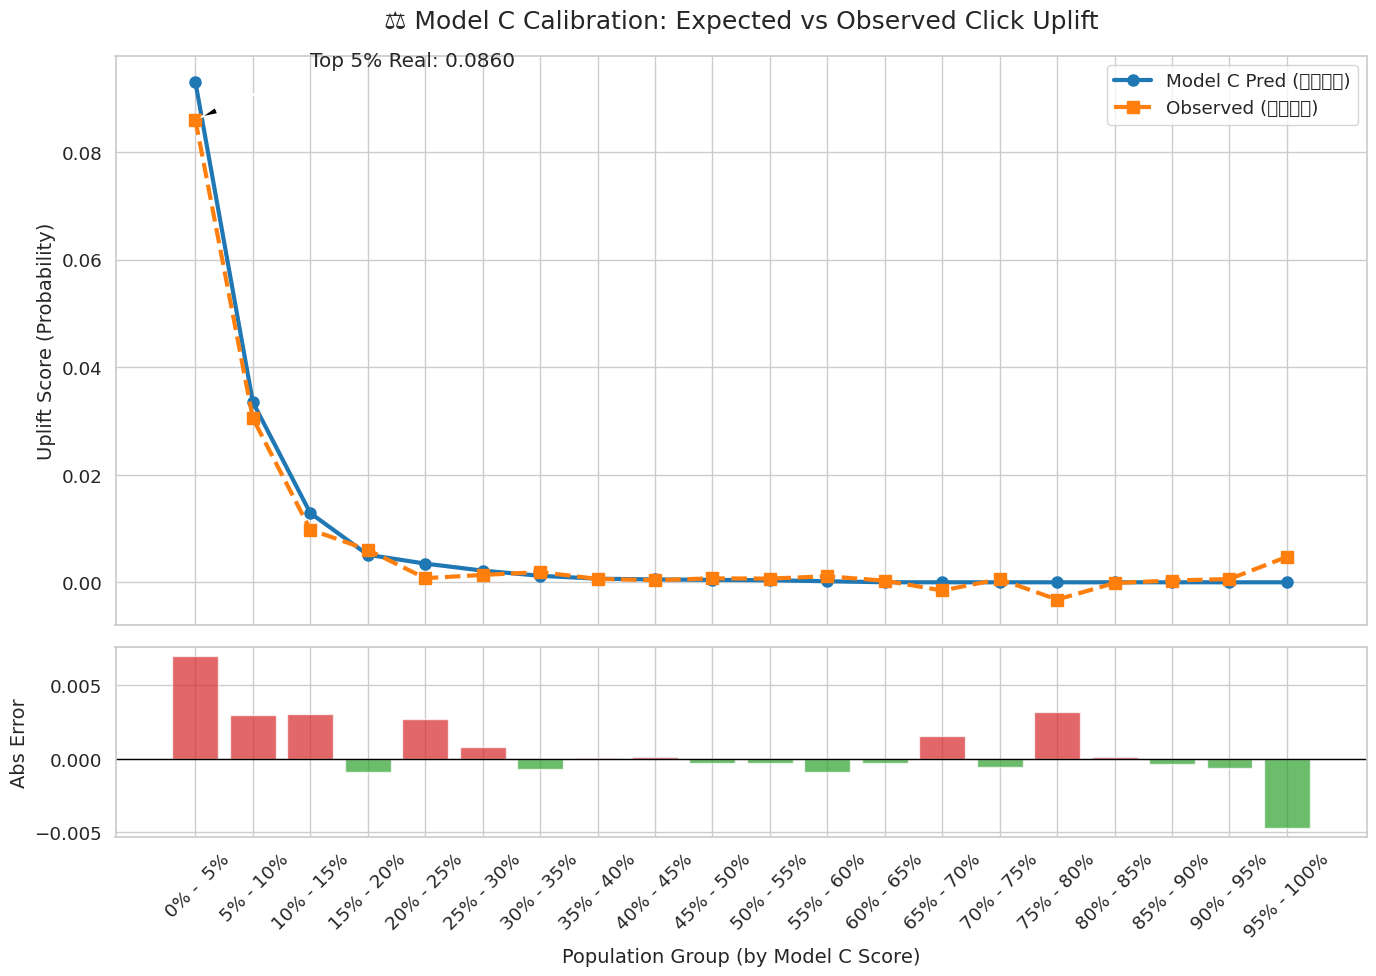

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
sns.set_theme(style="whitegrid", font_scale=1.2)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, 
                               gridspec_kw={'height_ratios': [3, 1]})

# --- 上图：预期 vs 现实 (对齐曲线) ---
x_labels = res_df.index
x_ticks = np.arange(len(x_labels))

ax1.plot(x_ticks, res_df['C_Pred_Uplift (预期)'], label='Model C Pred (预期增益)', 
         marker='o', color='#1f77b4', linewidth=3, markersize=8)
ax1.plot(x_ticks, res_df['Real_C_Uplift (现实)'], label='Observed (现实增益)', 
         marker='s', color='#ff7f0e', linestyle='--', linewidth=3, markersize=8)

ax1.set_title('⚖️ Model C Calibration: Expected vs Observed Click Uplift', fontsize=18, pad=20)
ax1.set_ylabel('Uplift Score (Probability)', fontsize=14)
ax1.legend(loc='upper right', frameon=True)

# --- 下图：绝对误差 (偏差分布) ---
# 用柱状图展示误差，红色代表高估，蓝色代表低估
colors = ['#d62728' if e > 0 else '#2ca02c' for e in res_df['Abs_Error (绝对误差)']]
ax2.bar(x_ticks, res_df['Abs_Error (绝对误差)'], color=colors, alpha=0.7)

ax2.set_ylabel('Abs Error', fontsize=14)
ax2.set_xlabel('Population Group (by Model C Score)', fontsize=14)
ax2.set_xticks(x_ticks)
ax2.set_xticklabels(x_labels, rotation=45)

# 画一条零线
ax2.axhline(0, color='black', linewidth=1, linestyle='-')

# 标注关键数据点
ax1.annotate(f'Top 5% Real: {top_5_real:.4f}', 
             xy=(0, top_5_real), xytext=(2, top_5_real + 0.01),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.tight_layout()

# 保存图片
plt.savefig("model_c_calibration.png", dpi=300, bbox_inches='tight')
print("\n✅ 可视化完成！图片已保存至: model_c_calibration.png")
plt.show()